## Fine-grain depth resolution (expanded layer3/layer4)

We plot probes over a mixed depth axis:
- **Coarse**: conv1, layer1, layer2
- **Fine**: each bottleneck block in layer3 and layer4 (e.g., layer3.0 … layer3.5; layer4.0 … layer4.2)
- **End**: avgpool

This gives higher resolution where semantic structure typically forms (late mid → deep layers), without making the x-axis too long early.


# Attribute-Based Emergence Analysis (Sharp-Rise)
**Dataset:** CUB-200-2011  
**Models:** Baseline ResNet-50 vs CBM backbone (ResNet-50 fine-tuned via CBM training)

## What we measure
For each target (species or attribute), we have a probe accuracy curve across layers.

**Sharp-rise emergence layer** = the layer where the accuracy curve shows the **largest jump** between consecutive layers  
(we return the *later* layer where that jump is realized)

This avoids arbitrary thresholds like “0.9×max”.


# Attribute-Based Emergence Analysis (Sharp-Rise)
**Dataset:** CUB-200-2011  
**Models:** Baseline ResNet-50 vs CBM backbone (ResNet-50 fine-tuned via CBM training)

## What we measure
For each target (species or attribute), we have a probe accuracy curve across layers.

**Sharp-rise emergence layer** = the layer where the accuracy curve shows the **largest jump** between consecutive layers  
(we return the *later* layer where that jump is realized)

This avoids arbitrary thresholds like “0.9×max”.


In [1]:
import os, sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)

sys.path.append(os.path.abspath(".."))


## Inputs: Probe JSONs

You should have probe result JSONs like:
- `results/probes/resnet50_cub_probes_attributes.json`
- `results/probes/resnet50_cub_cbm_probes_attributes.json`

If you later generate fine-grain probe JSONs, point to those instead — the notebook will auto-handle.


In [2]:
# ---- CHANGE THESE PATHS ----
BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes_fine.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes_fine.json")

assert BASELINE_JSON.exists(), f"Missing baseline probe JSON: {BASELINE_JSON}"
assert CBM_JSON.exists(), f"Missing cbm probe JSON: {CBM_JSON}"

print("Baseline JSON:", BASELINE_JSON)
print("CBM JSON     :", CBM_JSON)


Baseline JSON: /scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes_fine.json
CBM JSON     : /scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes_fine.json


## Load JSON → DataFrame (robust)

Expected JSON format: list of dict rows with at least:
- layer
- target_type
- target_name
- best_val_acc
- group
(and optionally: column, train_acc, val_acc, etc.)


In [3]:
def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f"Expected a list in JSON: {path}, got {type(data)}")
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = pd.concat(
    [
        load_probe_json(BASELINE_JSON, "baseline"),
        load_probe_json(CBM_JSON, "cbm"),
    ],
    ignore_index=True
)

required = {"layer", "target_type", "target_name", "best_val_acc", "group", "model"}
missing = required - set(df_all.columns)
assert not missing, f"JSON missing required columns: {missing}. Columns are: {list(df_all.columns)}"

print("Loaded df_all:", df_all.shape)
print("Models:", df_all["model"].unique())
print("Target types:", df_all["target_type"].unique())

df_all


Loaded df_all: (3960, 9)
Models: ['baseline' 'cbm']
Target types: ['subclass' 'attribute']


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model
0,conv1,subclass,species,species,0.022356,0.018985,0.018985,NaN,baseline
1,layer1.0,subclass,species,species,0.047381,0.037453,0.037970,NaN,baseline
2,layer1.1,subclass,species,species,0.049383,0.037625,0.037625,NaN,baseline
3,layer1.2,subclass,species,species,0.049383,0.033656,0.036072,NaN,baseline
4,layer2.0,subclass,species,species,0.074575,0.047290,0.047635,NaN,baseline
...,...,...,...,...,...,...,...,...,...
3955,avgpool,attribute,has_crown_color::white,has_crown_color,0.935102,0.913531,0.913876,attr_306_present,cbm
3956,avgpool,attribute,has_crown_color::buff,has_crown_color,0.900067,0.872972,0.875561,attr_308_present,cbm
3957,avgpool,attribute,has_wing_pattern::solid,has_wing_pattern,0.825325,0.760442,0.761995,attr_309_present,cbm
3958,avgpool,attribute,has_wing_pattern::striped,has_wing_pattern,0.802970,0.766828,0.782016,attr_311_present,cbm


## Layer ordering


- coarse layers: `conv1, layer1, layer2, layer3, layer4, avgpool`
- fine layers:  `layer1.0 ... layer4.2` etc (and mixed cases)

We infer the layer list from the JSON, then sort in ResNet order.


In [4]:
def _layer_sort_key(name: str):
    # order: conv1, layer1(.root), layer1.0..., layer2..., layer3..., layer4..., avgpool
    if name == "conv1":
        return (0, 0, 0)
    if name == "avgpool":
        return (99, 0, 0)

    m = re.match(r"layer([1-4])(?:\.(\d+))?$", str(name))
    if m:
        stage = int(m.group(1))
        block = m.group(2)
        if block is None:
            # "layer3" root goes before "layer3.0"
            return (stage, 0, -1)
        return (stage, 1, int(block))

    # unknown names go last
    return (50, 0, 0)

def infer_layers_ordered(df: pd.DataFrame) -> list[str]:
    layers = df["layer"].dropna().astype(str).unique().tolist()
    layers = sorted(layers, key=_layer_sort_key)
    return layers

LAYERS_ORDERED = infer_layers_ordered(df_all)
layer_to_idx = {l: i for i, l in enumerate(LAYERS_ORDERED)}

df_all = df_all.copy()
df_all["layer"] = df_all["layer"].astype(str)
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

print("Num layers inferred:", len(LAYERS_ORDERED))
print("First 20 layers:", LAYERS_ORDERED[:20])
print("Last 10 layers:", LAYERS_ORDERED[-10:])


Num layers inferred: 18
First 20 layers: ['conv1', 'layer1.0', 'layer1.1', 'layer1.2', 'layer2.0', 'layer2.1', 'layer2.2', 'layer2.3', 'layer3.0', 'layer3.1', 'layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']
Last 10 layers: ['layer3.0', 'layer3.1', 'layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']


In [32]:
# --- FORCE fine-grain ordering ---
LAYERS_ORDERED = [
    "conv1",
    "layer1.0","layer1.1","layer1.2",
    "layer2.0","layer2.1","layer2.2","layer2.3",
    "layer3.0","layer3.1","layer3.2","layer3.3","layer3.4","layer3.5",
    "layer4.0","layer4.1","layer4.2",
    "avgpool"
]
layer_to_idx = {l:i for i,l in enumerate(LAYERS_ORDERED)}

# --- SANITY: avgpool must be last and have idx 17 ---
assert LAYERS_ORDERED[-1] == "avgpool"
assert layer_to_idx["avgpool"] == len(LAYERS_ORDERED)-1 == 17

# --- SANITY: df_all layers must be subset of LAYERS_ORDERED (otherwise you are mixing formats) ---
unknown_layers = sorted(set(df_all["layer"].unique()) - set(LAYERS_ORDERED))
assert len(unknown_layers) == 0, f"df_all contains layers not in LAYERS_ORDERED: {unknown_layers[:20]}"

print("OK: using fine layers, num =", len(LAYERS_ORDERED), "avgpool idx =", layer_to_idx["avgpool"])


OK: using fine layers, num = 18 avgpool idx = 17


## Helper: Get a curve for a (target_type, target_name, model)

Returns a Pandas Series indexed by `LAYERS_ORDERED`, with values = best_val_acc per layer.
If duplicates exist, we take max per layer.
Missing layers remain NaN (then we ffill/bfill when computing jumps).


In [5]:
def get_curve(df: pd.DataFrame, target_type: str, target_name: str, model: str) -> pd.Series:
    sub = df[
        (df["model"] == model) &
        (df["target_type"] == target_type) &
        (df["target_name"] == target_name)
    ].copy()

    if sub.empty:
        return pd.Series(index=LAYERS_ORDERED, dtype=float)

    # max best_val_acc per layer
    sub = sub.groupby("layer", as_index=False)["best_val_acc"].max()
    sub["layer_idx"] = sub["layer"].map(layer_to_idx)
    sub = sub.sort_values("layer_idx")

    curve = pd.Series(sub["best_val_acc"].values, index=sub["layer"].values)
    return curve.reindex(LAYERS_ORDERED)


## Sharp-rise emergence layer

We:
1) fill missing values by forward/back fill (only for computing diffs)
2) compute diffs between consecutive layers
3) find argmax(diffs)
4) return the later layer (j+1)


In [6]:
def sharp_rise_layer(curve: pd.Series) -> str | None:
    vals = curve.values.astype(float)

    if np.all(np.isnan(vals)):
        return None

    # Fill NaNs so diff doesn't become NaN everywhere
    filled = pd.Series(vals).ffill().bfill().values
    diffs = np.diff(filled)

    if diffs.size == 0:
        return None

    j = int(np.argmax(diffs))
    return LAYERS_ORDERED[j + 1]


## Build a table of emergence results for all targets

`emerge_df` has one row per (model, target), with:
- max accuracy
- sharp-rise emergence layer
- layer_idx


In [7]:
targets = df_all[["target_type", "target_name", "group"]].drop_duplicates()

records = []
for _, row in targets.iterrows():
    ttype = row["target_type"]
    tname = row["target_name"]
    tgroup = row["group"]

    for model in ["baseline", "cbm"]:
        curve = get_curve(df_all, ttype, tname, model)
        if np.all(np.isnan(curve.values)):
            continue

        records.append({
            "model": model,
            "target_type": ttype,
            "target_name": tname,
            "group": tgroup,
            "max_acc": float(np.nanmax(curve.values)),
            "emergence_layer": sharp_rise_layer(curve),
        })

emerge_df = pd.DataFrame(records)
emerge_df["layer_idx"] = emerge_df["emergence_layer"].map(layer_to_idx)

print("emerge_df rows:", len(emerge_df))
emerge_df.head()


emerge_df rows: 220


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
0,baseline,subclass,species,species,0.730238,layer4.0,14
1,cbm,subclass,species,species,0.620642,layer4.0,14
2,baseline,attribute,has_bill_shape::dagger,has_bill_shape,0.880394,layer4.2,16
3,cbm,attribute,has_bill_shape::dagger,has_bill_shape,0.884191,layer4.0,14
4,baseline,attribute,has_bill_shape::all-purpose,has_bill_shape,0.719710,layer4.0,14


In [8]:
print("Targets:", emerge_df["target_type"].value_counts().to_dict())
print("Models:", emerge_df["model"].value_counts().to_dict())

# Species row check (if present)
species_rows = emerge_df[(emerge_df["target_type"] == "subclass") & (emerge_df["target_name"] == "species")]
species_rows


Targets: {'attribute': 218, 'subclass': 2}
Models: {'baseline': 110, 'cbm': 110}


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
0,baseline,subclass,species,species,0.730238,layer4.0,14
1,cbm,subclass,species,species,0.620642,layer4.0,14


## Plot: a single target curve (baseline vs cbm)


In [9]:
# CELL — Define fine-grained ResNet-50 layers (block-level)

def make_fine_layers():
    layers = ["conv1"]
    layers += [f"layer1.{i}" for i in range(3)]   # 3 blocks
    layers += [f"layer2.{i}" for i in range(4)]   # 4 blocks
    layers += [f"layer3.{i}" for i in range(6)]   # 6 blocks
    layers += [f"layer4.{i}" for i in range(3)]   # 3 blocks
    layers += ["avgpool"]
    return layers

LAYERS_ORDERED_FINE = make_fine_layers()
layer_to_idx_fine = {l: i for i, l in enumerate(LAYERS_ORDERED_FINE)}

print("Num fine layers:", len(LAYERS_ORDERED_FINE))
print(LAYERS_ORDERED_FINE)


Num fine layers: 18
['conv1', 'layer1.0', 'layer1.1', 'layer1.2', 'layer2.0', 'layer2.1', 'layer2.2', 'layer2.3', 'layer3.0', 'layer3.1', 'layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']


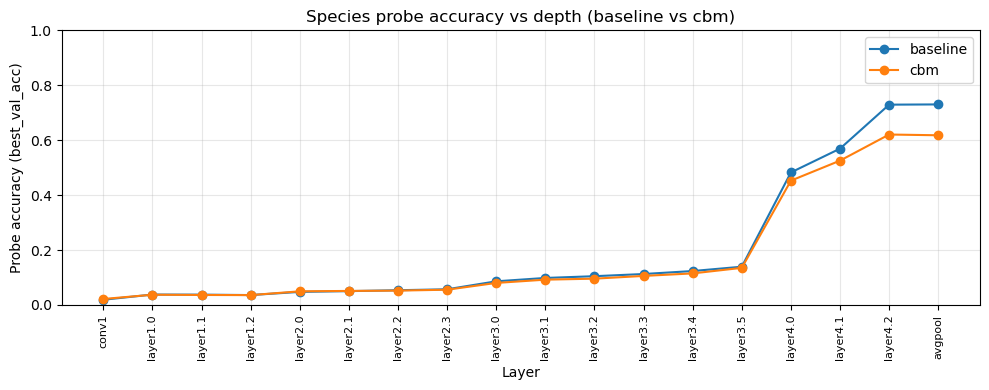

In [17]:
def plot_two_model_curves(target_type: str, target_name: str, title: str | None = None):
    c0 = get_curve(df_all, target_type, target_name, "baseline")
    c1 = get_curve(df_all, target_type, target_name, "cbm")

    x = np.arange(len(LAYERS_ORDERED))
    plt.figure(figsize=(max(10, len(LAYERS_ORDERED) * 0.35), 4))

    plt.plot(x, c0.values, marker="o", label="baseline")
    plt.plot(x, c1.values, marker="o", label="cbm")

    plt.xticks(x, LAYERS_ORDERED, rotation=90, fontsize=8)
    plt.ylim(0, 1.0)
    plt.xlabel("Layer")
    plt.ylabel("Probe accuracy (best_val_acc)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title if title else f"{target_type}: {target_name}")
    plt.tight_layout()
    plt.show()


# Species
plot_two_model_curves("subclass", "species", title="Species probe accuracy vs depth (baseline vs cbm)")



In [12]:
attr_names = sorted(df_all[df_all["target_type"] == "attribute"]["target_name"].unique().tolist())
print("Num attributes in JSON:", len(attr_names))

# Pick some representative attributes robustly:
#  - easiest (highest max_acc avg over models)
#  - hardest (lowest max_acc avg over models)
#  - most jumpy (largest jump avg over models)

attr_stats = []
for a in attr_names:
    rows = emerge_df[(emerge_df["target_type"] == "attribute") & (emerge_df["target_name"] == a)]
    if rows["model"].nunique() < 2:
        continue

    # compute jumpiness from curves
    def biggest_jump(model):
        c = get_curve(df_all, "attribute", a, model)
        v = pd.Series(c.values).ffill().bfill().values
        if len(v) < 2:
            return 0.0
        return float(np.max(np.diff(v)))

    max_acc_mean = rows["max_acc"].mean()
    jump_mean = 0.5 * (biggest_jump("baseline") + biggest_jump("cbm"))

    attr_stats.append((a, max_acc_mean, jump_mean))

attr_stats = pd.DataFrame(attr_stats, columns=["attr", "max_acc_mean", "jump_mean"])
easy = attr_stats.sort_values("max_acc_mean", ascending=False).iloc[0]["attr"]
hard = attr_stats.sort_values("max_acc_mean", ascending=True).iloc[0]["attr"]
jumpy = attr_stats.sort_values("jump_mean", ascending=False).iloc[0]["attr"]

picked = []
for a in [easy, hard, jumpy]:
    if a not in picked:
        picked.append(a)

print("Picked:", picked)
picked


Num attributes in JSON: 109
Picked: ['has_throat_color::yellow', 'has_size::small_(5_-_9_in)', 'has_underparts_color::white']


['has_throat_color::yellow',
 'has_size::small_(5_-_9_in)',
 'has_underparts_color::white']

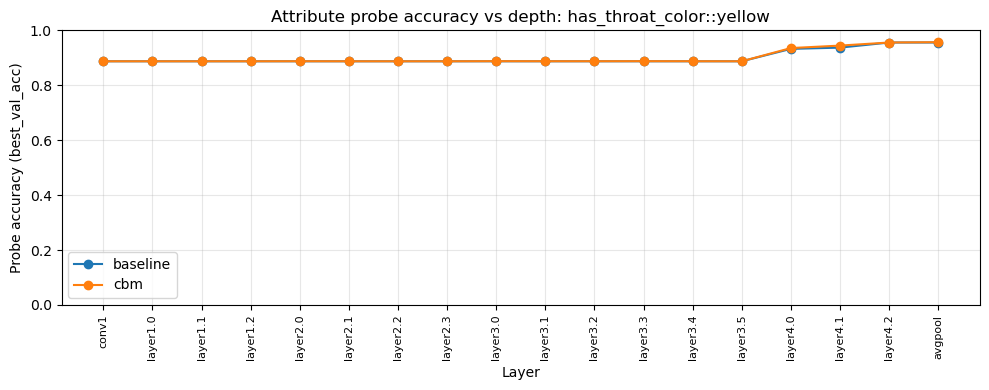

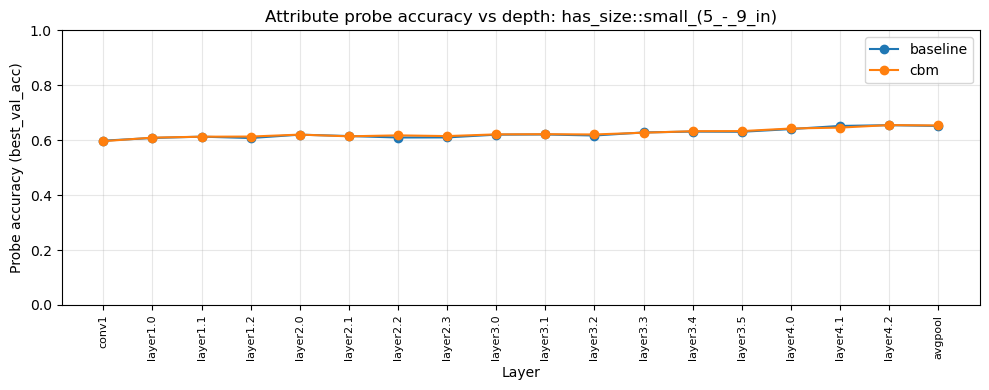

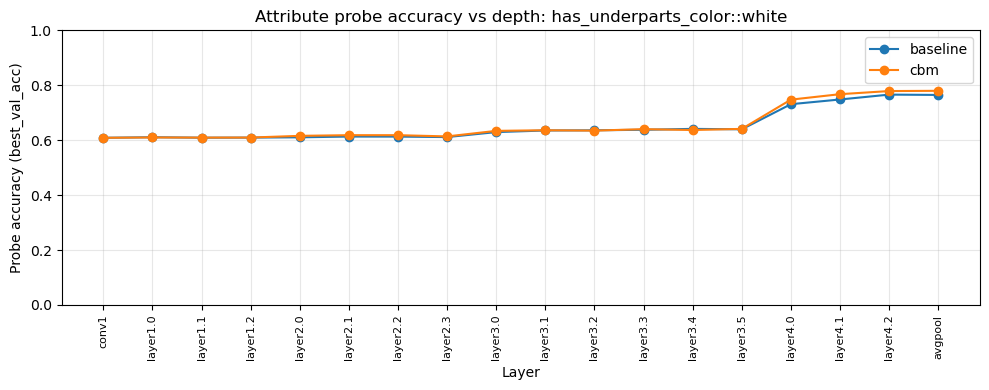

In [18]:
for a in picked:
    plot_two_model_curves("attribute", a, title=f"Attribute probe accuracy vs depth: {a}")


## Summary by attribute group

For each group (like `has_wing_color`), we compute:
- number of attributes in the group
- most common emergence layer
- mean emergence depth index

You can filter by minimum group size to avoid tiny groups dominating.


In [19]:
attr_only = emerge_df[emerge_df["target_type"] == "attribute"].copy()

group_counts = (
    attr_only.groupby(["model", "group"])
    .size()
    .rename("num_attributes")
    .reset_index()
)

group_mode_layer = (
    attr_only.groupby(["model", "group"])["emergence_layer"]
    .agg(lambda x: x.value_counts().index[0] if len(x) else None)
    .rename("mode_emergence_layer")
    .reset_index()
)

group_mean_depth = (
    attr_only.groupby(["model", "group"])["layer_idx"]
    .mean()
    .rename("mean_layer_idx")
    .reset_index()
)

group_summary = group_counts.merge(group_mode_layer, on=["model", "group"]).merge(group_mean_depth, on=["model", "group"])
group_summary = group_summary.sort_values(["model", "num_attributes"], ascending=[True, False])

MIN_ATTRS = 3
group_summary_filtered = group_summary[group_summary["num_attributes"] >= MIN_ATTRS]

print("Group summary (filtered):")
group_summary_filtered.head(30)


Group summary (filtered):


,model,group,num_attributes,mode_emergence_layer,mean_layer_idx
7,baseline,has_breast_color,6,layer4.2,15.000000
15,baseline,has_primary_color,6,layer4.0,14.000000
22,baseline,has_underparts_color,6,layer4.0,14.833333
0,baseline,has_back_color,5,layer4.0,14.600000
2,baseline,has_belly_color,5,layer4.0,14.400000
9,baseline,has_crown_color,5,layer4.0,14.600000
11,baseline,has_forehead_color,5,layer4.0,14.400000
12,baseline,has_head_pattern,5,layer4.0,14.800000
14,baseline,has_nape_color,5,layer4.0,14.200000
20,baseline,has_throat_color,5,layer4.0,14.800000


## Attributes whose sharp-rise occurs at/after species

Goal: find attributes whose **sharp-rise emergence layer index** is:
- strictly AFTER species (layer_idx > species_idx)
- exactly AT species (layer_idx == species_idx)

We’ll then plot their probe curves (baseline vs cbm) to see whether late attribute decodability
appears to “arrive with” species-level features.


In [20]:
# Choose which model's species emergence defines the reference point.
# Usually use baseline as the "natural" representation.
SPECIES_REF_MODEL = "baseline"   # or "cbm"

species_row = emerge_df[
    (emerge_df["target_type"] == "subclass") &
    (emerge_df["target_name"] == "species") &
    (emerge_df["model"] == SPECIES_REF_MODEL)
].iloc[0]

species_layer = species_row["emergence_layer"]
species_idx   = int(species_row["layer_idx"])

print("Species reference model:", SPECIES_REF_MODEL)
print("Species sharp-rise layer:", species_layer)
print("Species sharp-rise layer_idx:", species_idx, "out of", len(LAYERS_ORDERED)-1)


Species reference model: baseline
Species sharp-rise layer: layer4.0
Species sharp-rise layer_idx: 14 out of 17


In [21]:
attr_only = emerge_df[emerge_df["target_type"] == "attribute"].copy()

# If you want to be strict: require the attribute exists for BOTH models (baseline+cbm)
# so every plot has 2 curves.
attrs_in_both = (
    attr_only.groupby("target_name")["model"].nunique()
)
attrs_in_both = set(attrs_in_both[attrs_in_both == 2].index)

attr_only = attr_only[attr_only["target_name"].isin(attrs_in_both)].copy()

after_species = attr_only[attr_only["layer_idx"] > species_idx].copy()
at_species    = attr_only[attr_only["layer_idx"] == species_idx].copy()

print("Total attributes (present in both models):", attr_only["target_name"].nunique())
print("Attributes with sharp-rise AFTER species:", after_species["target_name"].nunique())
print("Attributes with sharp-rise AT species   :", at_species["target_name"].nunique())

# quick peek
display(after_species.sort_values(["layer_idx", "max_acc"], ascending=[True, False]).head(10))
display(at_species.sort_values(["max_acc"], ascending=False).head(10))


Total attributes (present in both models): 109
Attributes with sharp-rise AFTER species: 39
Attributes with sharp-rise AT species   : 92


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
29,cbm,attribute,has_underparts_color::brown,has_underparts_color,0.901450,layer4.1,15
70,baseline,attribute,has_upper_tail_color::buff,has_upper_tail_color,0.893165,layer4.1,15
42,baseline,attribute,has_breast_pattern::striped,has_breast_pattern,0.890059,layer4.1,15
43,cbm,attribute,has_breast_pattern::striped,has_breast_pattern,0.886434,layer4.1,15
171,cbm,attribute,has_tail_pattern::striped,has_tail_pattern,0.878150,layer4.1,15
55,cbm,attribute,has_back_color::buff,has_back_color,0.860891,layer4.1,15
138,baseline,attribute,has_nape_color::buff,has_nape_color,0.848464,layer4.1,15
60,baseline,attribute,has_tail_shape::pointed_tail,has_tail_shape,0.819296,layer4.1,15
158,baseline,attribute,has_size::very_small_(3_-_5_in),has_size,0.765965,layer4.1,15
192,baseline,attribute,has_leg_color::grey,has_leg_color,0.753366,layer4.1,15


,model,target_type,target_name,group,max_acc,emergence_layer,layer_idx
97,cbm,attribute,has_throat_color::yellow,has_throat_color,0.956852,layer4.0,14
96,baseline,attribute,has_throat_color::yellow,has_throat_color,0.955644,layer4.0,14
87,cbm,attribute,has_breast_color::yellow,has_breast_color,0.943562,layer4.0,14
33,cbm,attribute,has_underparts_color::yellow,has_underparts_color,0.940973,layer4.0,14
143,cbm,attribute,has_belly_color::yellow,has_belly_color,0.940801,layer4.0,14
142,baseline,attribute,has_belly_color::yellow,has_belly_color,0.940283,layer4.0,14
32,baseline,attribute,has_underparts_color::yellow,has_underparts_color,0.940110,layer4.0,14
86,baseline,attribute,has_breast_color::yellow,has_breast_color,0.939765,layer4.0,14
185,cbm,attribute,has_primary_color::yellow,has_primary_color,0.929755,layer4.0,14
184,baseline,attribute,has_primary_color::yellow,has_primary_color,0.927166,layer4.0,14


## Plotting policy

There can be many attributes in each bucket.
We’ll rank them with a score and plot the top-K:
- prefer attributes with high max_acc (actually decodable)
- prefer attributes with strong "jumpiness" (biggest jump in curve)

You can change TOPK to plot more.


Top AFTER species:


,attr,max_acc_mean,jump_mean,score
30,has_underparts_color::brown,0.901191,0.001899,0.902615
7,has_breast_color::brown,0.894373,0.003624,0.897092
15,has_head_pattern::eyebrow,0.890404,0.006213,0.895064
33,has_upper_tail_color::buff,0.893165,0.001036,0.893942
11,has_breast_pattern::striped,0.888246,0.002589,0.890188
6,has_bill_shape::dagger,0.880394,0.009061,0.887189
14,has_head_pattern::capped,0.886262,0.001208,0.887168
16,has_head_pattern::eyeline,0.885744,0.000518,0.886132
28,has_under_tail_color::buff,0.880911,0.000863,0.881559
12,has_crown_color::buff,0.877805,0.001294,0.878775


Top AT species:


,attr,max_acc_mean,jump_mean,score
72,has_underparts_color::yellow,0.940542,0.073093,0.995362
10,has_belly_color::yellow,0.940542,0.070245,0.993226
63,has_throat_color::yellow,0.956248,0.046686,0.991263
25,has_breast_color::yellow,0.941664,0.065930,0.991111
54,has_primary_color::yellow,0.928460,0.064722,0.977002
31,has_crown_color::white,0.913876,0.028564,0.935299
37,has_forehead_color::white,0.901363,0.032016,0.925375
6,has_belly_color::black,0.895927,0.031584,0.919615
60,has_throat_color::black,0.870728,0.057991,0.914222
12,has_belly_pattern::striped,0.904039,0.000949,0.904751


Plotting 12 attributes — Sharp-rise AFTER species

ATTR: has_underparts_color::brown
  baseline emergence: avgpool (idx=17)
  cbm      emergence: layer4.1 (idx=15)
  species reference: layer4.0 (idx=14)  [model=baseline]


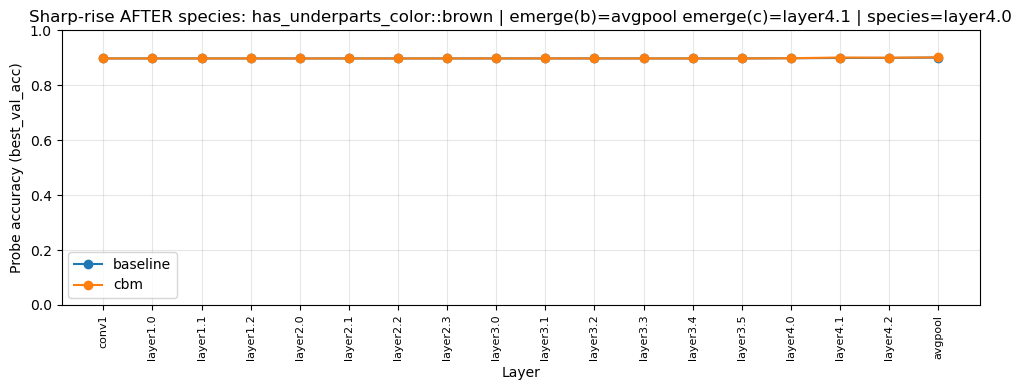


ATTR: has_breast_color::brown
  baseline emergence: layer4.2 (idx=16)
  cbm      emergence: layer4.2 (idx=16)
  species reference: layer4.0 (idx=14)  [model=baseline]


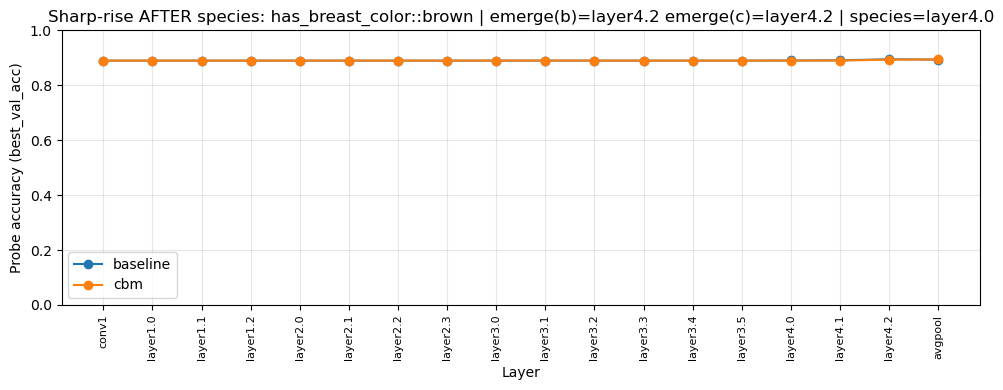


ATTR: has_head_pattern::eyebrow
  baseline emergence: layer4.2 (idx=16)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


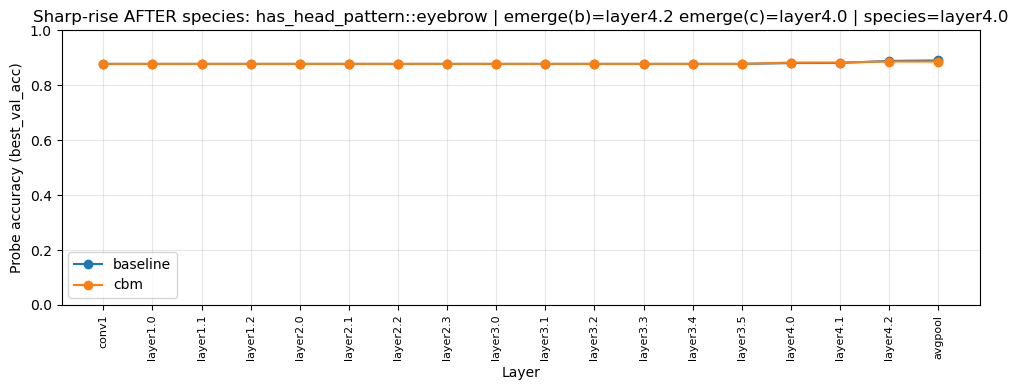


ATTR: has_upper_tail_color::buff
  baseline emergence: layer4.1 (idx=15)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


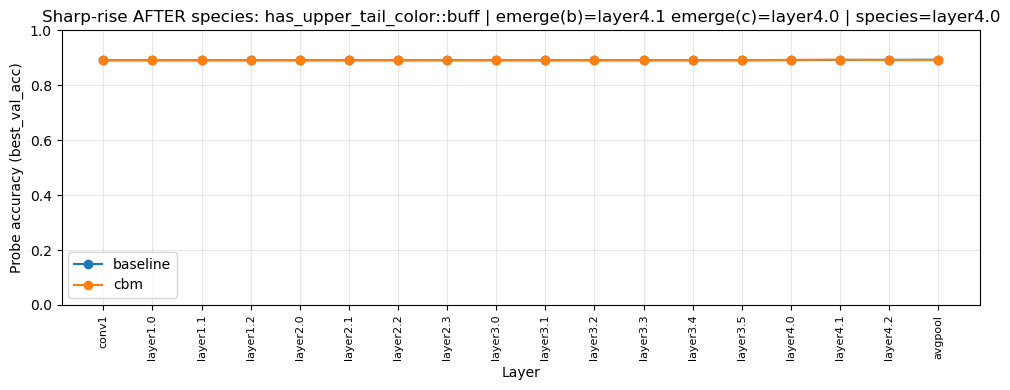


ATTR: has_breast_pattern::striped
  baseline emergence: layer4.1 (idx=15)
  cbm      emergence: layer4.1 (idx=15)
  species reference: layer4.0 (idx=14)  [model=baseline]


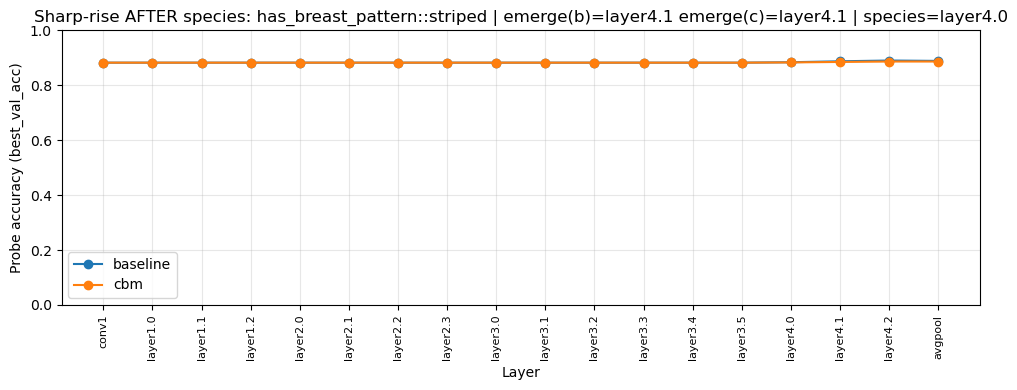


ATTR: has_bill_shape::dagger
  baseline emergence: layer4.2 (idx=16)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


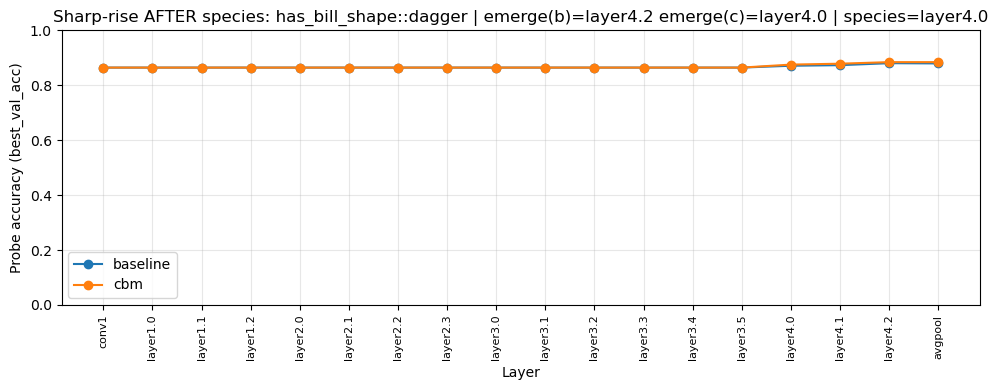


ATTR: has_head_pattern::capped
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.2 (idx=16)
  species reference: layer4.0 (idx=14)  [model=baseline]


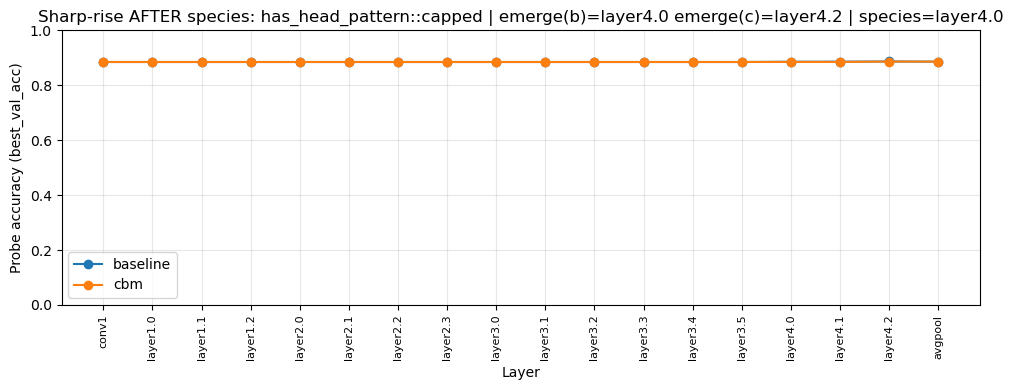


ATTR: has_head_pattern::eyeline
  baseline emergence: layer4.2 (idx=16)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


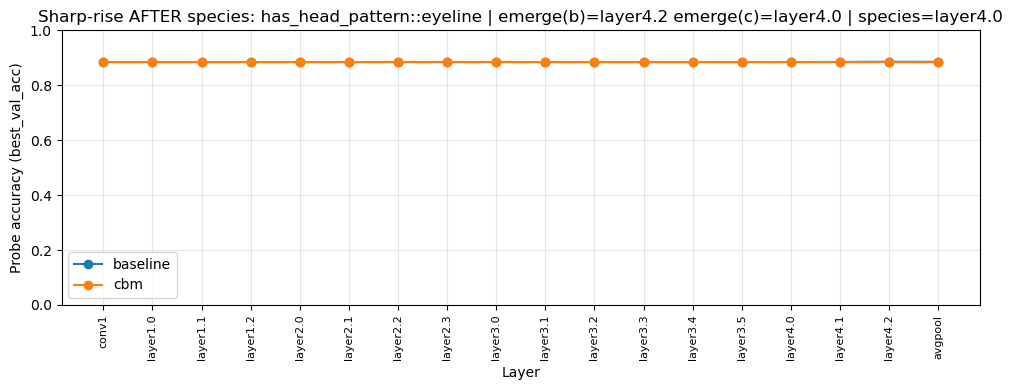


ATTR: has_under_tail_color::buff
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: avgpool (idx=17)
  species reference: layer4.0 (idx=14)  [model=baseline]


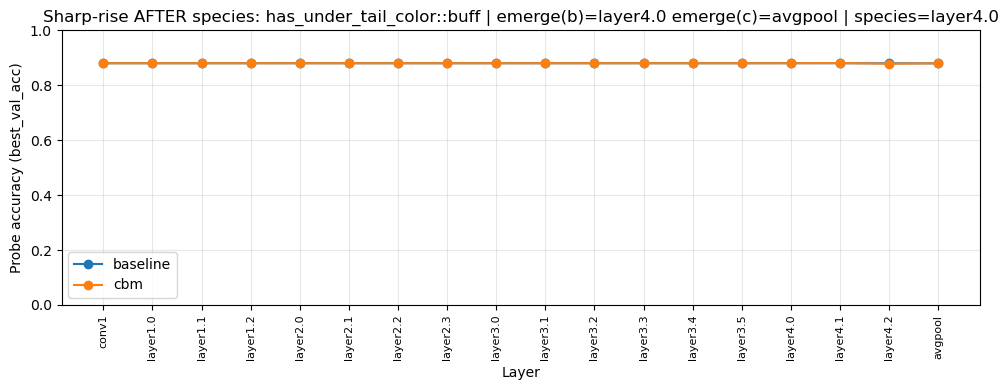


ATTR: has_crown_color::buff
  baseline emergence: avgpool (idx=17)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


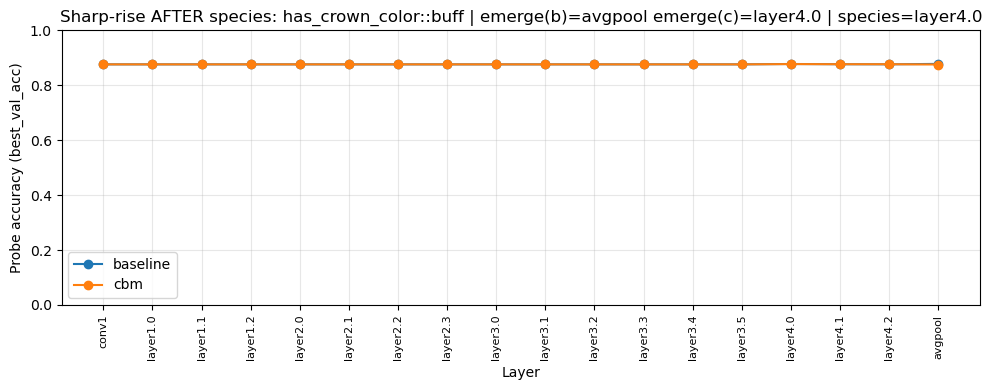


ATTR: has_tail_pattern::striped
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.1 (idx=15)
  species reference: layer4.0 (idx=14)  [model=baseline]


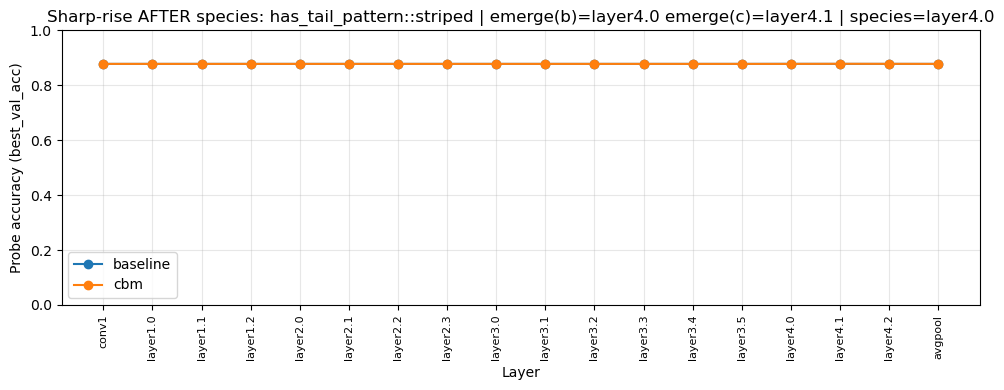


ATTR: has_throat_color::buff
  baseline emergence: layer4.2 (idx=16)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


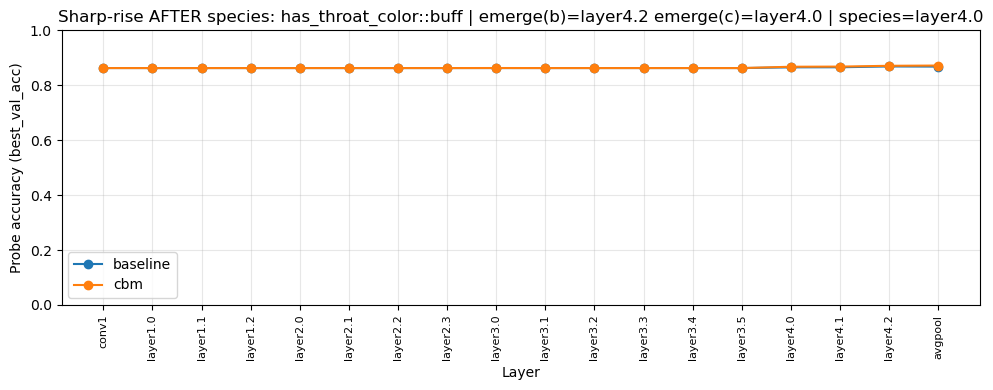

Plotting 12 attributes — Sharp-rise AT species

ATTR: has_underparts_color::yellow
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


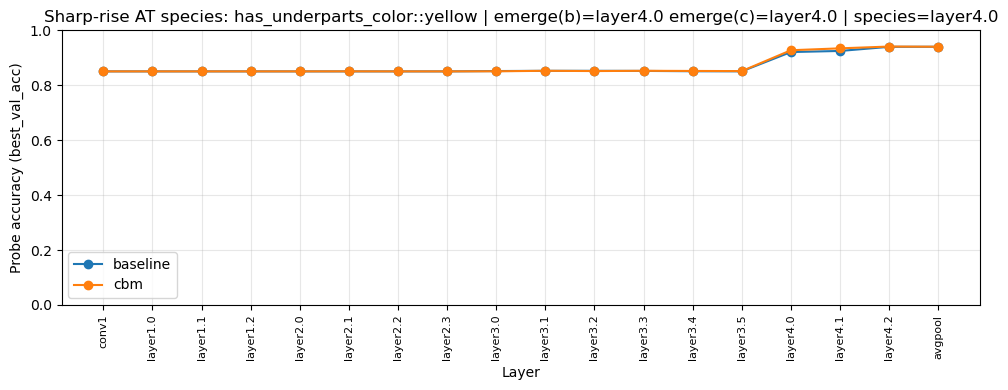


ATTR: has_belly_color::yellow
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


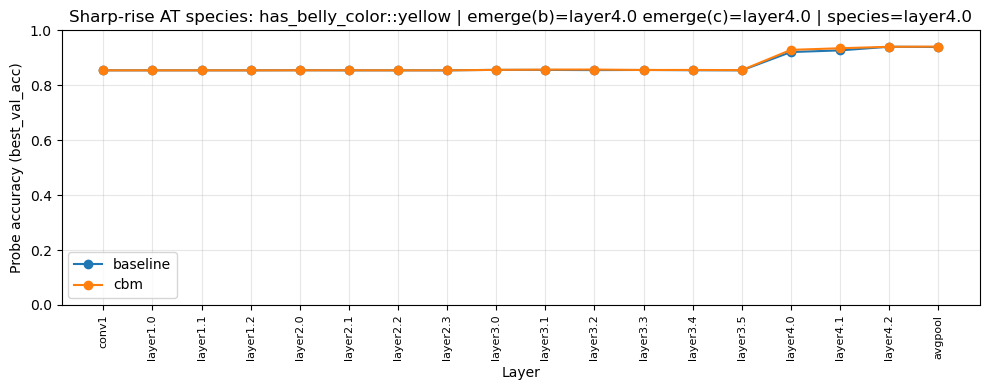


ATTR: has_throat_color::yellow
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


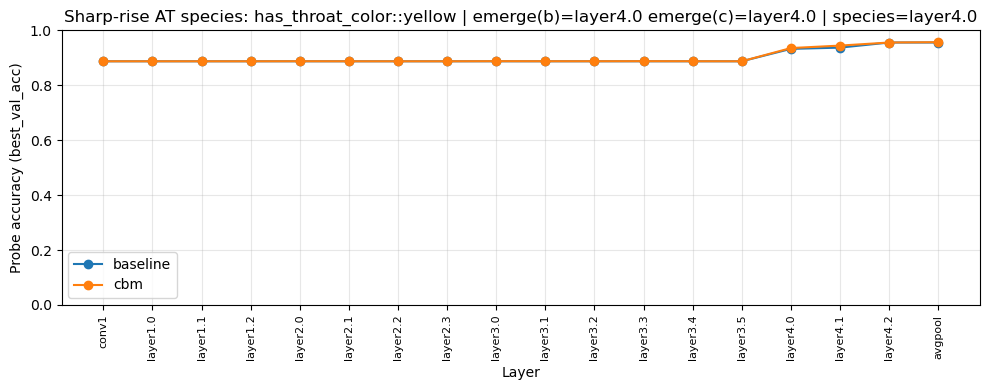


ATTR: has_breast_color::yellow
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


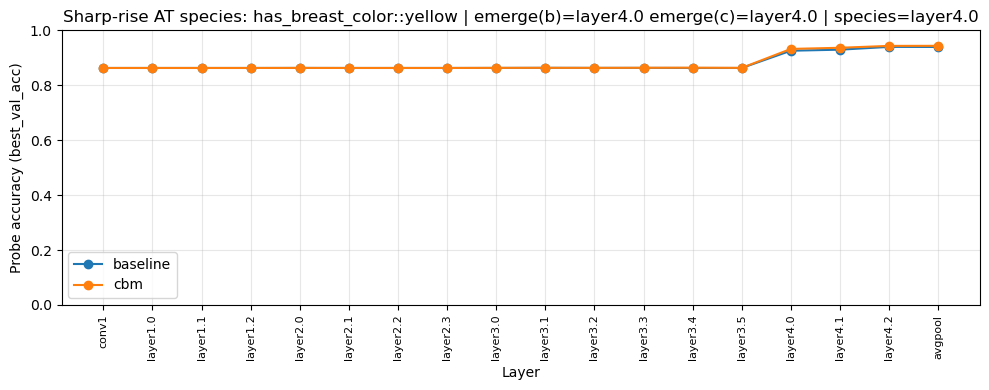


ATTR: has_primary_color::yellow
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


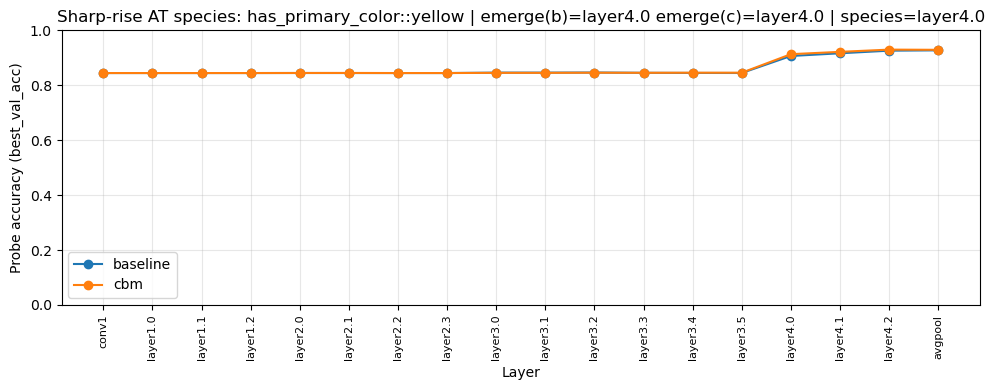


ATTR: has_crown_color::white
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


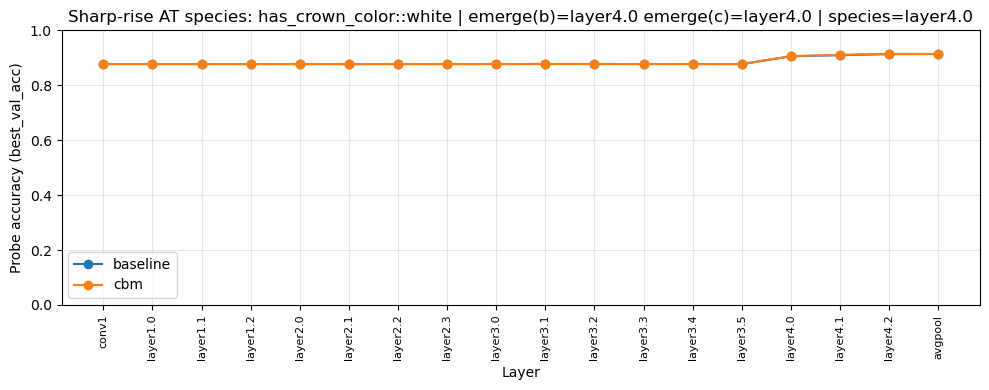


ATTR: has_forehead_color::white
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


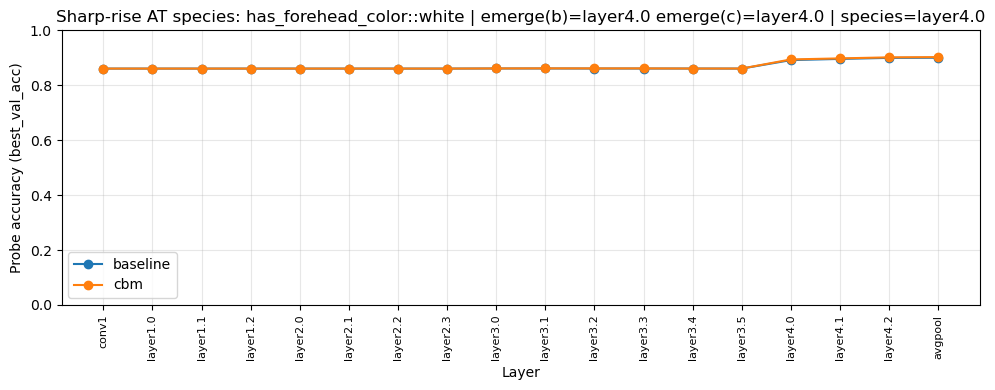


ATTR: has_belly_color::black
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


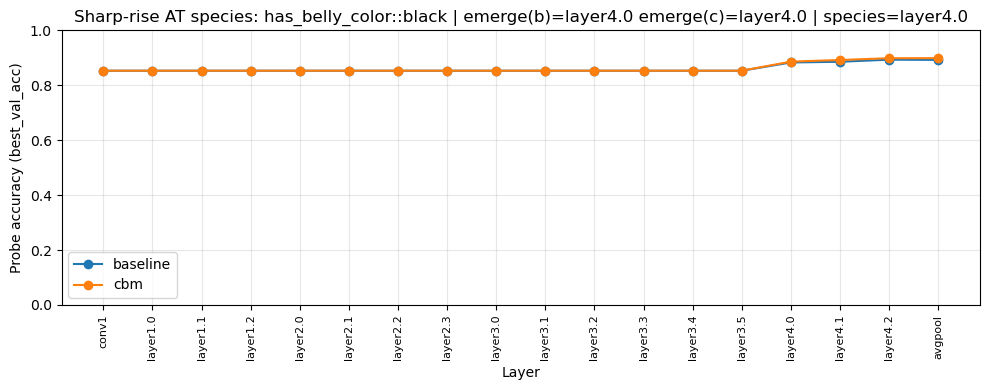


ATTR: has_throat_color::black
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


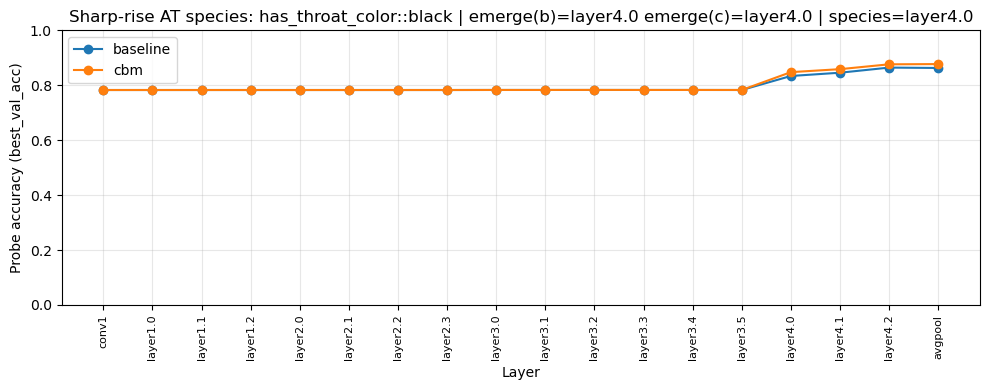


ATTR: has_belly_pattern::striped
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


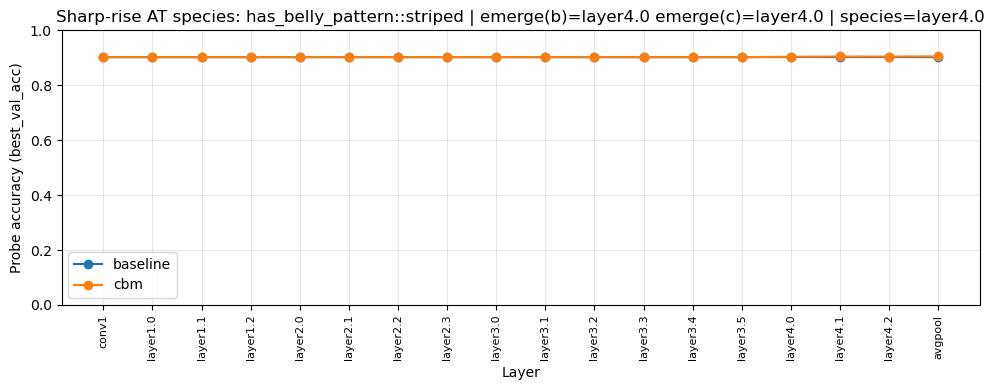


ATTR: has_underparts_color::black
  baseline emergence: layer4.0 (idx=14)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


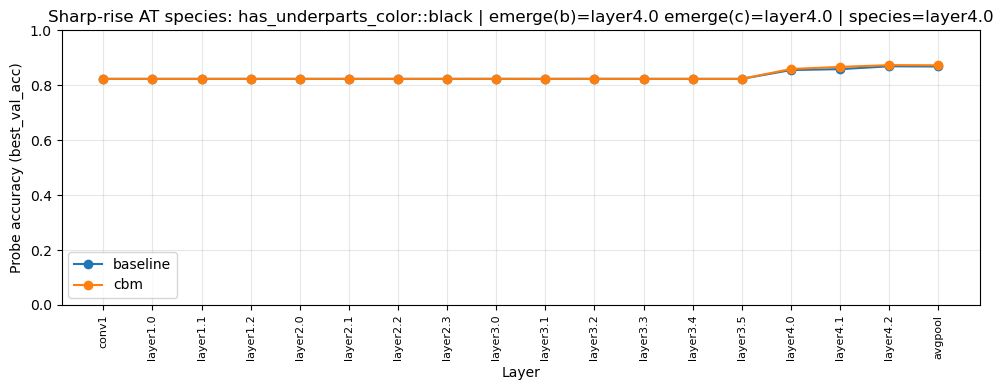


ATTR: has_upper_tail_color::buff
  baseline emergence: layer4.1 (idx=15)
  cbm      emergence: layer4.0 (idx=14)
  species reference: layer4.0 (idx=14)  [model=baseline]


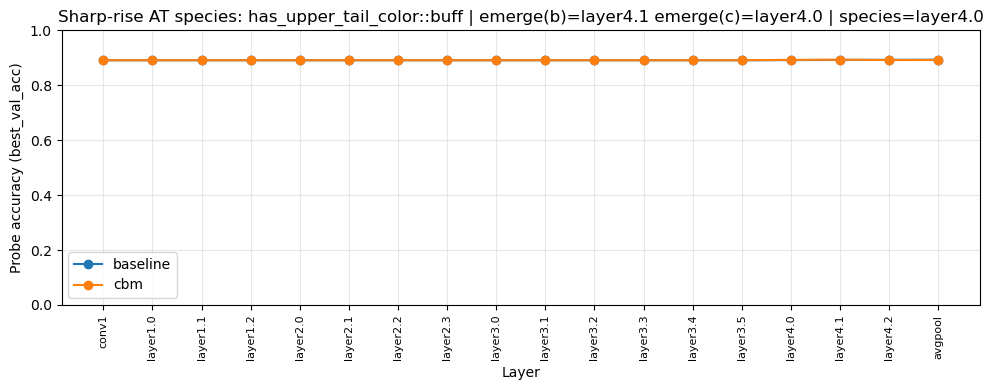

In [26]:
TOPK = 12  # change to e.g. 30 if you want more plots

def biggest_jump_for_attr(attr_name: str, model: str) -> float:
    c = get_curve(df_all, "attribute", attr_name, model)
    v = pd.Series(c.values).ffill().bfill().values
    if len(v) < 2:
        return 0.0
    return float(np.max(np.diff(v)))

def make_rank_table(bucket_df: pd.DataFrame) -> pd.DataFrame:
    # one row per attribute per model exists already in bucket_df
    # collapse to attribute-level info for ranking
    rows = []
    for a in sorted(bucket_df["target_name"].unique()):
        m = bucket_df[bucket_df["target_name"] == a]["max_acc"].mean()
        j = 0.5 * (biggest_jump_for_attr(a, "baseline") + biggest_jump_for_attr(a, "cbm"))
        rows.append({"attr": a, "max_acc_mean": m, "jump_mean": j, "score": m + 0.75*j})
    return pd.DataFrame(rows).sort_values("score", ascending=False)

rank_after = make_rank_table(after_species)
rank_at    = make_rank_table(at_species)

print("Top AFTER species:")
display(rank_after.head(15))

print("Top AT species:")
display(rank_at.head(15))

def attr_emergence_layer(attr_name: str, model: str):
    r = emerge_df[
        (emerge_df["target_type"] == "attribute") &
        (emerge_df["target_name"] == attr_name) &
        (emerge_df["model"] == model)
    ]
    if r.empty:
        return None, None
    r = r.iloc[0]
    return r["emergence_layer"], int(r["layer_idx"])

def plot_bucket(rank_df: pd.DataFrame, title_prefix: str):
    to_plot = rank_df.head(TOPK)["attr"].tolist()
    print(f"Plotting {len(to_plot)} attributes — {title_prefix}")
    for a in to_plot:
        e_base, i_base = attr_emergence_layer(a, "baseline")
        e_cbm,  i_cbm  = attr_emergence_layer(a, "cbm")

        print(f"\nATTR: {a}")
        print(f"  baseline emergence: {e_base} (idx={i_base})")
        print(f"  cbm      emergence: {e_cbm} (idx={i_cbm})")
        print(f"  species reference: {species_layer} (idx={species_idx})  [model={SPECIES_REF_MODEL}]")

        plot_two_model_curves(
            "attribute",
            a,
            title=f"{title_prefix}: {a} | emerge(b)={e_base} emerge(c)={e_cbm} | species={species_layer}"
        )
plot_bucket(rank_after, "Sharp-rise AFTER species")
plot_bucket(rank_at, "Sharp-rise AT species")


## A *more diagnostic* view (very relevant): align curves around the species emergence point

Instead of eyeballing dozens of lines, we can compute:

For each attribute, how much accuracy improves:
- **before species** (layers < species_idx)
- **at/after species** (layers >= species_idx)

Then compare baseline vs cbm.

This directly addresses:
- “Do attributes get their boost mainly at species?”
- “Does CBM shift where that boost occurs?”


In [24]:
def curve_stats_relative_to_species(attr_name: str, model: str):
    c = get_curve(df_all, "attribute", attr_name, model)
    v = pd.Series(c.values).ffill().bfill().values

    pre  = v[:species_idx]              # strictly before species layer
    post = v[species_idx:]              # at and after species layer

    pre_mean  = float(np.mean(pre)) if len(pre) else float("nan")
    post_mean = float(np.mean(post)) if len(post) else float("nan")

    # “gain at/after species”: last - value just before species (or first if no pre)
    if species_idx > 0:
        gain = float(v[-1] - v[species_idx-1])
    else:
        gain = float(v[-1] - v[0])

    # local jump at species boundary (species_idx-1 -> species_idx), if possible
    boundary_jump = float(v[species_idx] - v[species_idx-1]) if species_idx > 0 else 0.0

    return pre_mean, post_mean, gain, boundary_jump, float(v[-1])

rows = []
for a in sorted(attr_only["target_name"].unique()):
    pre_b, post_b, gain_b, bj_b, fin_b = curve_stats_relative_to_species(a, "baseline")
    pre_c, post_c, gain_c, bj_c, fin_c = curve_stats_relative_to_species(a, "cbm")

    rows.append({
        "attr": a,
    
        # Final probe accuracy (best_val at the last layer in LAYERS_ORDERED, after ffill/bfill)
        "baseline_final": fin_b,
        "cbm_final": fin_c,
    
        # Final accuracy difference at the last layer: + means CBM is better at predicting this attribute
        "final_gap_cbm_minus_base": fin_c - fin_b,
    
        # "Boundary jump": how much the curve jumps exactly at the species boundary:
        # boundary is between layer (species_idx - 1) -> (species_idx)
        # Example (fine): layer3.5 -> layer4.0
        "baseline_boundary_jump": bj_b,
        "cbm_boundary_jump": bj_c,
    
        # Difference in that boundary jump: + means CBM has a bigger jump at the boundary
        "boundary_jump_gap": bj_c - bj_b,
    
        # "Post-species gain": improvement from just-before-species to final layer.
        # gain = final_acc - acc_at_(species_idx - 1)
        # Captures whether most of the attribute performance comes after species emerges.
        "baseline_gain_postSpecies": gain_b,
        "cbm_gain_postSpecies": gain_c,
    
        # Difference in post-species gain: + means CBM gains more after species boundary
        "gain_gap": gain_c - gain_b,
    })


rel_df = pd.DataFrame(rows)

# Interesting: attributes where CBM makes a *bigger* jump exactly around species
display(rel_df.sort_values("boundary_jump_gap", ascending=False).head(20))

# Interesting: attributes where CBM improves final accuracy a lot
display(rel_df.sort_values("final_gap_cbm_minus_base", ascending=False).head(20))


,attr,baseline_final,cbm_final,final_gap_cbm_minus_base,baseline_boundary_jump,cbm_boundary_jump,boundary_jump_gap,baseline_gain_postSpecies,cbm_gain_postSpecies,gain_gap
20,has_bill_length::shorter_than_head,0.762513,0.769589,0.007076,0.048153,0.073697,0.025544,0.082844,0.096134,0.013290
60,has_primary_color::grey,0.740249,0.761995,0.021747,0.024336,0.046600,0.022264,0.037798,0.059544,0.021747
16,has_bill_color::black,0.688643,0.703832,0.015188,0.058854,0.080946,0.022092,0.091474,0.101484,0.010010
33,has_crown_color::black,0.813945,0.817915,0.003970,0.086987,0.107698,0.020711,0.131170,0.127891,-0.003279
55,has_nape_color::grey,0.782534,0.801346,0.018813,0.012599,0.032793,0.020193,0.028823,0.047635,0.018813
39,has_forehead_color::black,0.800138,0.802727,0.002589,0.084915,0.104073,0.019158,0.119606,0.120987,0.001381
102,has_wing_color::grey,0.725578,0.742147,0.016569,0.015706,0.033828,0.018122,0.029513,0.046600,0.017087
87,has_underparts_color::white,0.764757,0.779772,0.015016,0.091474,0.106489,0.015016,0.125129,0.138592,0.013462
97,has_upperparts_color::grey,0.738695,0.752330,0.013635,0.021056,0.035554,0.014498,0.033656,0.046945,0.013290
73,has_throat_color::black,0.862962,0.877114,0.014153,0.051087,0.064895,0.013807,0.080255,0.094235,0.013980


,attr,baseline_final,cbm_final,final_gap_cbm_minus_base,baseline_boundary_jump,cbm_boundary_jump,boundary_jump_gap,baseline_gain_postSpecies,cbm_gain_postSpecies,gain_gap
60,has_primary_color::grey,0.740249,0.761995,0.021747,0.024336,0.046600,0.022264,0.037798,0.059544,0.021747
55,has_nape_color::grey,0.782534,0.801346,0.018813,0.012599,0.032793,0.020193,0.028823,0.047635,0.018813
102,has_wing_color::grey,0.725578,0.742147,0.016569,0.015706,0.033828,0.018122,0.029513,0.046600,0.017087
28,has_breast_color::white,0.765620,0.780980,0.015361,0.087332,0.091129,0.003797,0.108906,0.116845,0.007939
16,has_bill_color::black,0.688643,0.703832,0.015188,0.058854,0.080946,0.022092,0.091474,0.101484,0.010010
87,has_underparts_color::white,0.764757,0.779772,0.015016,0.091474,0.106489,0.015016,0.125129,0.138592,0.013462
73,has_throat_color::black,0.862962,0.877114,0.014153,0.051087,0.064895,0.013807,0.080255,0.094235,0.013980
97,has_upperparts_color::grey,0.738695,0.752330,0.013635,0.021056,0.035554,0.014498,0.033656,0.046945,0.013290
57,has_primary_color::black,0.765102,0.776838,0.011736,0.075768,0.076631,0.000863,0.088712,0.089748,0.001036
11,has_belly_color::white,0.768381,0.779772,0.011391,0.089230,0.103038,0.013807,0.118744,0.130135,0.011391


## Recall and Prevelence

In [33]:
import numpy as np
import pandas as pd

def get_curve(df: pd.DataFrame, *, model: str, target_type: str, target_name: str) -> pd.Series:
    sub = df[(df["model"]==model) & (df["target_type"]==target_type) & (df["target_name"]==target_name)].copy()
    if sub.empty:
        return pd.Series(index=LAYERS_ORDERED, dtype=float)

    sub = sub.groupby("layer", as_index=False)["best_val_acc"].max()
    sub["layer_idx"] = sub["layer"].map(layer_to_idx)
    sub = sub.sort_values("layer_idx")

    curve = pd.Series(sub["best_val_acc"].values, index=sub["layer"].values)
    return curve.reindex(LAYERS_ORDERED)

def sharp_rise_idx(curve: pd.Series) -> int | None:
    vals = curve.values.astype(float)
    if np.all(np.isnan(vals)):
        return None
    vals_ff = pd.Series(vals).ffill().bfill().values
    diffs = np.diff(vals_ff)
    j = int(np.argmax(diffs))     # jump from j -> j+1
    return j + 1

def boundary_jump(curve: pd.Series, boundary_idx: int) -> float:
    """
    Jump across boundary: (boundary_idx-1) -> (boundary_idx)
    boundary_idx must be in [1, len(LAYERS_ORDERED)-1]
    """
    vals_ff = pd.Series(curve.values.astype(float)).ffill().bfill().values
    if boundary_idx <= 0 or boundary_idx >= len(vals_ff):
        return float("nan")
    return float(vals_ff[boundary_idx] - vals_ff[boundary_idx-1])


In [34]:
models = sorted(df_all["model"].unique())

species_info = []
for m in models:
    curve_sp = get_curve(df_all, model=m, target_type="subclass", target_name="species")
    sp_idx = sharp_rise_idx(curve_sp)
    species_info.append({
        "model": m,
        "species_idx": sp_idx,
        "species_layer": (LAYERS_ORDERED[sp_idx] if sp_idx is not None else None),
        "species_max_acc": float(np.nanmax(curve_sp.values)),
    })

species_info = pd.DataFrame(species_info)
display(species_info)

# extra sanity:
for _, r in species_info.iterrows():
    assert r["species_idx"] is None or 0 <= int(r["species_idx"]) < len(LAYERS_ORDERED)


,model,species_idx,species_layer,species_max_acc
0,baseline,14,layer4.0,0.730238
1,cbm,14,layer4.0,0.620642


In [35]:
MODEL = "baseline"  # or "cbm"
species_idx = int(species_info.loc[species_info["model"]==MODEL, "species_idx"].iloc[0])

print("MODEL:", MODEL)
print("species_idx:", species_idx, "->", LAYERS_ORDERED[species_idx])
print("Boundary is:", LAYERS_ORDERED[species_idx-1], "->", LAYERS_ORDERED[species_idx])

attr_names = (
    df_all[df_all["target_type"]=="attribute"]["target_name"]
    .drop_duplicates().tolist()
)

rows = []
for a in attr_names:
    curve = get_curve(df_all, model=MODEL, target_type="attribute", target_name=a)
    sr = sharp_rise_idx(curve)
    if sr is None:
        continue

    rows.append({
        "attr": a,
        "group": df_all.loc[(df_all["target_type"]=="attribute") & (df_all["target_name"]==a), "group"].iloc[0],
        "attr_sharp_rise_idx": sr,
        "attr_sharp_rise_layer": LAYERS_ORDERED[sr],          # <-- what you asked: emergent layer too
        "attr_max_acc": float(np.nanmax(curve.values)),
        "jump_at_species_boundary": boundary_jump(curve, species_idx),
    })

attr_stats = pd.DataFrame(rows)
display(attr_stats.head())


MODEL: baseline
species_idx: 14 -> layer4.0
Boundary is: layer3.5 -> layer4.0


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary
0,has_bill_shape::dagger,has_bill_shape,16,layer4.2,0.880394,0.006731
1,has_bill_shape::all-purpose,has_bill_shape,14,layer4.0,0.719710,0.057473
2,has_bill_shape::cone,has_bill_shape,14,layer4.0,0.808250,0.035899
3,has_wing_color::brown,has_wing_color,14,layer4.0,0.794443,0.047463
4,has_wing_color::grey,has_wing_color,14,layer4.0,0.727132,0.015706


In [36]:
cand = attr_stats[attr_stats["attr_sharp_rise_idx"] >= species_idx].copy()

equal_species = cand[cand["attr_sharp_rise_idx"] == species_idx].copy()
after_species = cand[cand["attr_sharp_rise_idx"] >  species_idx].copy()

print("Total attrs:", len(attr_stats))
print("Candidates (>= species):", len(cand))
print("== species:", len(equal_species))
print(">  species:", len(after_species))

display(equal_species.sort_values(["attr_max_acc","jump_at_species_boundary"], ascending=False).head(25))
display(after_species.sort_values(["attr_max_acc","jump_at_species_boundary"], ascending=False).head(25))


Total attrs: 109
Candidates (>= species): 107
== species: 73
>  species: 34


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary
47,has_throat_color::yellow,has_throat_color,14,layer4.0,0.955644,0.045219
70,has_belly_color::yellow,has_belly_color,14,layer4.0,0.940283,0.066621
15,has_underparts_color::yellow,has_underparts_color,14,layer4.0,0.940110,0.070245
42,has_breast_color::yellow,has_breast_color,14,layer4.0,0.939765,0.062824
91,has_primary_color::yellow,has_primary_color,14,layer4.0,0.927166,0.061961
104,has_crown_color::white,has_crown_color,14,layer4.0,0.913531,0.028478
87,has_belly_pattern::striped,has_belly_pattern,14,layer4.0,0.902831,0.000518
57,has_forehead_color::white,has_forehead_color,14,layer4.0,0.900242,0.030894
71,has_belly_color::black,has_belly_color,14,layer4.0,0.893165,0.030031
39,has_head_pattern::capped,has_head_pattern,14,layer4.0,0.886607,0.001036


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary
13,has_underparts_color::brown,has_underparts_color,17,avgpool,0.900932,0.000690
40,has_breast_color::brown,has_breast_color,16,layer4.2,0.894719,0.000518
34,has_upper_tail_color::buff,has_upper_tail_color,15,layer4.1,0.893165,0.000518
35,has_head_pattern::eyebrow,has_head_pattern,16,layer4.2,0.890404,0.002761
20,has_breast_pattern::striped,has_breast_pattern,15,layer4.1,0.890059,0.001553
38,has_head_pattern::eyeline,has_head_pattern,16,layer4.2,0.885744,0.000000
0,has_bill_shape::dagger,has_bill_shape,16,layer4.2,0.880394,0.006731
105,has_crown_color::buff,has_crown_color,17,avgpool,0.877805,0.001381
50,has_throat_color::buff,has_throat_color,16,layer4.2,0.868485,0.002589
30,has_upper_tail_color::brown,has_upper_tail_color,16,layer4.2,0.859337,0.000690


In [37]:
# simple score (tune weights)
cand["score"] = 0.7*cand["attr_max_acc"] + 0.3*cand["jump_at_species_boundary"]

interesting = cand.sort_values(
    by=["jump_at_species_boundary","attr_max_acc"],
    ascending=False
)

display(interesting.head(30))


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary,score
49,has_throat_color::white,has_throat_color,14,layer4.0,0.790818,0.093200,0.581533
17,has_underparts_color::white,has_underparts_color,14,layer4.0,0.765965,0.091474,0.563618
72,has_belly_color::white,has_belly_color,14,layer4.0,0.768381,0.089230,0.564636
44,has_breast_color::white,has_breast_color,14,layer4.0,0.765620,0.087332,0.562133
103,has_crown_color::black,has_crown_color,14,layer4.0,0.813945,0.086987,0.595858
56,has_forehead_color::black,has_forehead_color,14,layer4.0,0.800138,0.084915,0.585571
92,has_primary_color::black,has_primary_color,14,layer4.0,0.766655,0.075768,0.559389
15,has_underparts_color::yellow,has_underparts_color,14,layer4.0,0.940110,0.070245,0.679151
70,has_belly_color::yellow,has_belly_color,14,layer4.0,0.940283,0.066621,0.678184
66,has_nape_color::black,has_nape_color,14,layer4.0,0.824474,0.066275,0.597014


In [ ]:
# Columns meaning:
# - attr:            attribute label, e.g. "has_throat_color::yellow"
# - group:           high-level attribute group, e.g. "has_throat_color"
# - attr_sharp_rise_idx:
#       index in LAYERS_ORDERED where the *largest* increase in accuracy occurs between consecutive layers.
#       If the max jump is from layer k -> k+1, we record k+1 (the layer where the jump is realized).
# - attr_sharp_rise_layer:
#       same as above but human-readable layer name.
# - attr_max_acc:
#       maximum probe accuracy over all layers (lets you prefer attributes whose probes actually work).
# - jump_at_species_boundary:
#       accuracy(layer=species_idx) - accuracy(layer=species_idx-1).
#       This measures whether the attribute probe improves *right at the species jump boundary*.
#       Large values here are your “interesting” cases.
# - score (later):
#       combined heuristic to shortlist (high max_acc and big boundary jump).

In [38]:
# CELL A — Fine-grain layer list + utilities

import json
import numpy as np
import pandas as pd
from pathlib import Path

# If you already have this list, keep yours.
# Otherwise infer from your printout:
LAYERS = [
    "conv1",
    "layer1.0","layer1.1","layer1.2",
    "layer2.0","layer2.1","layer2.2","layer2.3",
    "layer3.0","layer3.1","layer3.2","layer3.3","layer3.4","layer3.5",
    "layer4.0","layer4.1","layer4.2",
    "avgpool",
]
layer_to_idx = {l:i for i,l in enumerate(LAYERS)}

def ffill_bfill(vals: np.ndarray) -> np.ndarray:
    """Fill NaNs so diffs don't explode when a layer is missing in the JSON."""
    return pd.Series(vals).ffill().bfill().to_numpy()

def sharp_rise_idx(curve_vals: np.ndarray) -> int:
    """
    Sharp-rise index = argmax over consecutive layer jumps.
    Returns the *later* layer index (i+1) where the jump is realized.
    """
    v = curve_vals.astype(float)
    if np.all(np.isnan(v)):
        return -1
    v = ffill_bfill(v)
    diffs = np.diff(v)
    j = int(np.argmax(diffs))
    return j + 1


In [39]:
# CELL B — Load probe JSONs

BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

assert BASELINE_JSON.exists(), f"Missing {BASELINE_JSON}"
assert CBM_JSON.exists(), f"Missing {CBM_JSON}"

def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    data = json.loads(path.read_text())
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = pd.concat(
    [load_probe_json(BASELINE_JSON, "baseline"),
     load_probe_json(CBM_JSON, "cbm")],
    ignore_index=True
)

# Keep only layers we know how to order
df_all = df_all[df_all["layer"].isin(LAYERS)].copy()
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

# If duplicates exist, keep best
df_all = (
    df_all
    .groupby(["model","target_type","target_name","group","layer"], as_index=False)["best_val_acc"]
    .max()
)
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

print("df_all:", df_all.shape)
print("models:", df_all["model"].unique())
print("target_types:", df_all["target_type"].unique())
print("num layers:", len(LAYERS))
print("first 8:", LAYERS[:8])
print("last 8:", LAYERS[-8:])


df_all: (440, 7)
models: ['baseline' 'cbm']
target_types: ['attribute' 'subclass']
num layers: 18
first 8: ['conv1', 'layer1.0', 'layer1.1', 'layer1.2', 'layer2.0', 'layer2.1', 'layer2.2', 'layer2.3']
last 8: ['layer3.2', 'layer3.3', 'layer3.4', 'layer3.5', 'layer4.0', 'layer4.1', 'layer4.2', 'avgpool']


In [40]:
# CELL C — Species sharp-rise per model (this defines species_idx)

def get_curve_vals(model: str, target_type: str, target_name: str) -> np.ndarray:
    sub = df_all[
        (df_all["model"] == model) &
        (df_all["target_type"] == target_type) &
        (df_all["target_name"] == target_name)
    ].copy()

    # Reindex onto full layer list
    s = sub.set_index("layer")["best_val_acc"]
    vals = np.array([s.get(l, np.nan) for l in LAYERS], dtype=float)
    return vals

species_rows = []
for model in ["baseline","cbm"]:
    v = get_curve_vals(model, "subclass", "species")
    sp_idx = sharp_rise_idx(v)
    sp_layer = LAYERS[sp_idx] if sp_idx >= 0 else None
    sp_max = float(np.nanmax(v))
    species_rows.append({
        "model": model,
        "species_idx": sp_idx,
        "species_layer": sp_layer,
        "species_max_acc": sp_max,
        "species_boundary_from": LAYERS[sp_idx-1] if sp_idx > 0 else None,
        "species_boundary_to": sp_layer
    })

species_df = pd.DataFrame(species_rows)
display(species_df)

# species_idx is the integer index in LAYERS of the layer where the *largest* species jump occurs.


,model,species_idx,species_layer,species_max_acc,species_boundary_from,species_boundary_to
0,baseline,17,avgpool,0.727822,layer4.2,avgpool
1,cbm,17,avgpool,0.620297,layer4.2,avgpool


In [41]:
# CELL D — Attribute shortlist table (sharp-rise >= species), with clear column meanings

def attribute_summary_for_model(model: str) -> pd.DataFrame:
    # Species reference (where species "emerges" by sharp-rise)
    sp_vals = get_curve_vals(model, "subclass", "species")
    species_idx = sharp_rise_idx(sp_vals)

    # The "species boundary" jump for each attribute:
    # jump_at_species_boundary(attr) = acc[species_idx] - acc[species_idx-1]
    # This tests whether the attribute curve jumps right where species jumps.
    boundary_from = species_idx - 1

    # Build per-attribute stats
    attrs = (
        df_all[(df_all["model"] == model) & (df_all["target_type"] == "attribute")]
        [["target_name","group"]].drop_duplicates()
        .rename(columns={"target_name":"attr"})
        .reset_index(drop=True)
    )

    rows = []
    for _, r in attrs.iterrows():
        a = r["attr"]
        g = r["group"]
        v = get_curve_vals(model, "attribute", a)

        a_idx = sharp_rise_idx(v)
        a_layer = LAYERS[a_idx] if a_idx >= 0 else None

        vmax = float(np.nanmax(v))
        vff = ffill_bfill(v)

        if boundary_from >= 0:
            jump_boundary = float(vff[species_idx] - vff[boundary_from])
        else:
            jump_boundary = float("nan")

        # score: tune weights as you like
        # - max_acc ensures probe is meaningful
        # - jump_at_species_boundary targets your "interesting" hypothesis
        score = 0.65 * vmax + 0.35 * (jump_boundary if np.isfinite(jump_boundary) else 0.0)

        rows.append({
            "attr": a,                       # attribute name e.g., has_throat_color::yellow
            "group": g,                      # coarse attribute family e.g., has_throat_color
            "attr_sharp_rise_idx": a_idx,     # integer index into LAYERS where attribute sharp-rise occurs
            "attr_sharp_rise_layer": a_layer,# the actual layer string at that index
            "attr_max_acc": vmax,            # maximum probe accuracy across layers (best_val_acc)
            "jump_at_species_boundary": jump_boundary,  # acc jump exactly across species boundary
            "score": score                   # combined ranking score (heuristic)
        })

    out = pd.DataFrame(rows)
    out["species_idx"] = species_idx
    out["species_layer"] = LAYERS[species_idx]
    out["species_boundary"] = f"{LAYERS[species_idx-1]} -> {LAYERS[species_idx]}" if species_idx > 0 else "N/A"
    return out

baseline_attr_tbl = attribute_summary_for_model("baseline")
cbm_attr_tbl      = attribute_summary_for_model("cbm")

print("baseline species boundary:", baseline_attr_tbl["species_boundary"].iloc[0], " (species_idx =", baseline_attr_tbl["species_idx"].iloc[0], ")")
print("cbm species boundary:", cbm_attr_tbl["species_boundary"].iloc[0], " (species_idx =", cbm_attr_tbl["species_idx"].iloc[0], ")")


baseline species boundary: layer4.2 -> avgpool  (species_idx = 17 )
cbm species boundary: layer4.2 -> avgpool  (species_idx = 17 )


In [42]:
# CELL E — Your workflow: shortlist attrs where sharp-rise >= species, then split == vs >.

def shortlist_and_split(attr_tbl: pd.DataFrame, topk=30) -> tuple[pd.DataFrame,pd.DataFrame,pd.DataFrame]:
    species_idx = int(attr_tbl["species_idx"].iloc[0])

    cand = attr_tbl[attr_tbl["attr_sharp_rise_idx"] >= species_idx].copy()
    cand = cand.sort_values(["score","attr_max_acc"], ascending=False)

    eq = cand[cand["attr_sharp_rise_idx"] == species_idx].copy()
    gt = cand[cand["attr_sharp_rise_idx"] >  species_idx].copy()

    return cand, eq, gt

cand_b, eq_b, gt_b = shortlist_and_split(baseline_attr_tbl)
cand_c, eq_c, gt_c = shortlist_and_split(cbm_attr_tbl)

print("BASELINE candidates:", len(cand_b), " / total:", len(baseline_attr_tbl))
print("  == species:", len(eq_b))
print("  >  species:", len(gt_b))
display(eq_b.head(30))

print("\nCBM candidates:", len(cand_c), " / total:", len(cbm_attr_tbl))
print("  == species:", len(eq_c))
print("  >  species:", len(gt_c))
display(eq_c.head(30))


BASELINE candidates: 108  / total: 109
  == species: 108
  >  species: 0


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary,score,species_idx,species_layer,species_boundary
77,has_throat_color::yellow,has_throat_color,17,avgpool,0.955471,0.116155,0.661710,17,avgpool,layer4.2 -> avgpool
12,has_belly_color::yellow,has_belly_color,17,avgpool,0.941491,0.125820,0.656006,17,avgpool,layer4.2 -> avgpool
88,has_underparts_color::yellow,has_underparts_color,17,avgpool,0.939938,0.116327,0.651674,17,avgpool,layer4.2 -> avgpool
29,has_breast_color::yellow,has_breast_color,17,avgpool,0.939593,0.116672,0.651571,17,avgpool,layer4.2 -> avgpool
62,has_primary_color::yellow,has_primary_color,17,avgpool,0.926821,0.096824,0.636322,17,avgpool,layer4.2 -> avgpool
37,has_crown_color::white,has_crown_color,17,avgpool,0.913531,0.094753,0.626959,17,avgpool,layer4.2 -> avgpool
43,has_forehead_color::white,has_forehead_color,17,avgpool,0.899724,0.082672,0.613756,17,avgpool,layer4.2 -> avgpool
8,has_belly_color::black,has_belly_color,17,avgpool,0.895064,0.061961,0.603478,17,avgpool,layer4.2 -> avgpool
15,has_belly_pattern::striped,has_belly_pattern,17,avgpool,0.902831,0.030376,0.597472,17,avgpool,layer4.2 -> avgpool
45,has_head_pattern::eyebrow,has_head_pattern,17,avgpool,0.888505,0.053158,0.596134,17,avgpool,layer4.2 -> avgpool



CBM candidates: 109  / total: 109
  == species: 109
  >  species: 0


,attr,group,attr_sharp_rise_idx,attr_sharp_rise_layer,attr_max_acc,jump_at_species_boundary,score,species_idx,species_layer,species_boundary
12,has_belly_color::yellow,has_belly_color,17,avgpool,0.940110,0.128754,0.656136,17,avgpool,layer4.2 -> avgpool
77,has_throat_color::yellow,has_throat_color,17,avgpool,0.956507,0.091301,0.653685,17,avgpool,layer4.2 -> avgpool
29,has_breast_color::yellow,has_breast_color,17,avgpool,0.943045,0.099413,0.647774,17,avgpool,layer4.2 -> avgpool
88,has_underparts_color::yellow,has_underparts_color,17,avgpool,0.940973,0.103038,0.647696,17,avgpool,layer4.2 -> avgpool
62,has_primary_color::yellow,has_primary_color,17,avgpool,0.929237,0.115119,0.644296,17,avgpool,layer4.2 -> avgpool
43,has_forehead_color::white,has_forehead_color,17,avgpool,0.901795,0.078012,0.613471,17,avgpool,layer4.2 -> avgpool
37,has_crown_color::white,has_crown_color,17,avgpool,0.914049,0.054712,0.613281,17,avgpool,layer4.2 -> avgpool
8,has_belly_color::black,has_belly_color,17,avgpool,0.898171,0.071798,0.608940,17,avgpool,layer4.2 -> avgpool
15,has_belly_pattern::striped,has_belly_pattern,17,avgpool,0.904384,0.050915,0.605670,17,avgpool,layer4.2 -> avgpool
73,has_throat_color::black,has_throat_color,17,avgpool,0.877459,0.097342,0.604418,17,avgpool,layer4.2 -> avgpool


In [45]:
ATTR = "has_throat_color::white"   # choose from your table
MODEL = "baseline"                 # or "cbm"
LAYER = "layer4.0"                 # use attr_sharp_rise_layer for this attr


In [47]:
from pathlib import Path

CUB = Path("/scratch/network/cr7998/cv_emergence_project/data/CUB_200_2011")
path = CUB / "attributes/image_attribute_labels.txt"

bad_line_num = 709498  # 1-indexed line number from the pandas error
with open(path, "r") as f:
    for i, line in enumerate(f, start=1):
        if i == bad_line_num:
            print("RAW LINE:", repr(line))
            toks = line.strip().split()
            print("TOKENS:", toks)
            print("NUM TOKENS:", len(toks))
            break


RAW LINE: '2275 10 0 1 0  1.509\n'
TOKENS: ['2275', '10', '0', '1', '0', '1.509']
NUM TOKENS: 6


In [48]:
import numpy as np
import pandas as pd

rows = []
bad = 0

with open(path, "r") as f:
    for line in f:
        toks = line.strip().split()
        if len(toks) < 4:
            bad += 1
            continue
        try:
            # keep first 4 tokens; ignore extras safely
            image_id, attr_id, is_present, certainty = map(int, toks[:4])
            rows.append((image_id, attr_id, is_present, certainty))
        except ValueError:
            bad += 1

img_attr_long = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
print("Parsed rows:", len(img_attr_long), "bad lines skipped:", bad)
img_attr_long.head()


Parsed rows: 3677856 bad lines skipped: 0


,image_id,attr_id,is_present,certainty
0,1,1,0,3
1,1,2,0,3
2,1,3,0,3
3,1,4,0,3
4,1,5,1,3


In [49]:
from pathlib import Path
p = Path("/scratch/network/cr7998/cv_emergence_project/features/resnet50_cub")
print(sorted([x.name for x in p.glob("*.pt")])[:50])


['avgpool_test.pt', 'avgpool_train.pt', 'conv1_test.pt', 'conv1_train.pt', 'labels_test.pt', 'labels_train.pt', 'layer1_test.pt', 'layer1_train.pt', 'layer2_test.pt', 'layer2_train.pt', 'layer3_test.pt', 'layer3_train.pt', 'layer4_test.pt', 'layer4_train.pt']


In [50]:
# image_id -> species_id
img_species = pd.read_csv(
    CUB / "image_class_labels.txt",
    sep=r"\s+",
    header=None,
    names=["image_id", "species_id"]
)

# attribute name -> id
ATTR_TXT1 = Path("/scratch/network/cr7998/cv_emergence_project/data/attributes.txt")
ATTR_TXT2 = CUB / "attributes/attributes.txt"
attr_map_path = ATTR_TXT1 if ATTR_TXT1.exists() else ATTR_TXT2

attr_map = pd.read_csv(attr_map_path, sep=r"\s+", header=None, names=["attr_id", "attr_name"])
attr_map["attr_id"] = attr_map["attr_id"].astype(int)

ATTR = "has_throat_color::white"  # change if neede
attr_id = int(attr_map.loc[attr_map["attr_name"] == ATTR, "attr_id"].iloc[0])

y_attr = (
    img_attr_long[img_attr_long["attr_id"] == attr_id][["image_id","is_present","certainty"]]
    .merge(img_species, on="image_id", how="inner")
)

# Stronger labels: keep only visible-ish labels
y_attr = y_attr[y_attr["certainty"] >= 3].copy()
print("Rows:", len(y_attr))
y_attr.head()


Rows: 10794


,image_id,is_present,certainty,species_id
0,1,0,4,1
1,2,0,4,1
2,3,0,3,1
3,4,0,3,1
4,5,0,3,1


image_id: the unique ID of an image in CUB (1..11788).

is_present: the human annotation for whether the attribute is present in that image.
1 = attribute present, 0 = not present.

certainty: how confident the annotator was (usually 1..4; 4 = most confident).

species_id: which bird species the image is (1..200).

In [51]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd

# --- paths ---
ROOT = Path("/scratch/network/cr7998/cv_emergence_project")
CUB_ROOT = ROOT / "data" / "CUB_200_2011"
FEAT_DIR = ROOT / "features" / "resnet50_cub"  # baseline; for cbm change to resnet50_cub_cbm

# --- import your dataset class ---
from datasets.cub_dataset import CUBDataset  # matches your extract_features.py

def extract_image_id_from_item(item):
    """
    Try hard to extract image_id from a dataset __getitem__ return.
    Common patterns:
      (img, label, image_id)
      (img, label, meta_dict)
      (img, label) where dataset has .image_ids list, etc.
    """
    if isinstance(item, tuple) or isinstance(item, list):
        # look for int-like scalar
        for x in item[::-1]:
            if isinstance(x, (int, np.integer)):
                return int(x)
            if torch.is_tensor(x) and x.ndim == 0:
                return int(x.item())
            if isinstance(x, dict):
                for k in ["image_id", "img_id", "id"]:
                    if k in x:
                        return int(x[k])
    if isinstance(item, dict):
        for k in ["image_id", "img_id", "id"]:
            if k in item:
                return int(item[k])
    return None

def get_split_image_ids(split: str, limit_debug=3):
    ds = CUBDataset(str(CUB_ROOT), split=split, transform=None)  # transform doesn't affect ordering
    # Debug what one element looks like
    for i in range(min(limit_debug, len(ds))):
        it = ds[i]
        print(f"{split} ds[{i}] type/len:", type(it), (len(it) if isinstance(it, (tuple,list)) else None))

    ids = []
    for i in range(len(ds)):
        it = ds[i]
        img_id = extract_image_id_from_item(it)
        if img_id is None:
            break
        ids.append(img_id)

    if len(ids) == len(ds):
        return ids

    # Fallbacks if __getitem__ didn't expose image_id directly
    for attr in ["image_ids", "img_ids", "ids", "image_id_list"]:
        if hasattr(ds, attr):
            ids = list(map(int, getattr(ds, attr)))
            return ids

    raise RuntimeError(
        f"Could not extract image_id ordering from CUBDataset(split={split}). "
        "Please open datasets/cub_dataset.py and tell me what __getitem__ returns."
    )

train_image_ids = get_split_image_ids("train")
test_image_ids  = get_split_image_ids("test")

print("train N:", len(train_image_ids))
print("test  N:", len(test_image_ids))


train ds[0] type/len: <class 'dict'> None
train ds[1] type/len: <class 'dict'> None
train ds[2] type/len: <class 'dict'> None
test ds[0] type/len: <class 'dict'> None
test ds[1] type/len: <class 'dict'> None
test ds[2] type/len: <class 'dict'> None
train N: 5994
test  N: 5794


In [64]:
X4 = torch.load(BASELINE_FEAT_DIR/"layer4_test.pt", map_location="cpu")
Xa = torch.load(BASELINE_FEAT_DIR/"avgpool_test.pt", map_location="cpu")
print("max abs diff:", (X4 - Xa).abs().max().item())
print("same tensor storage:", X4.data_ptr() == Xa.data_ptr())


max abs diff: 0.0
same tensor storage: False


/tmp/ipykernel_3068958/1800959919.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X4 = torch.load(BASELINE_FEAT_DIR/"layer4_test.pt", map_location="cpu")
/tmp/ipykernel_

In [52]:
Xtr = torch.load(FEAT_DIR / "layer4_train.pt", map_location="cpu")
Xte = torch.load(FEAT_DIR / "layer4_test.pt",  map_location="cpu")

print("Xtr:", tuple(Xtr.shape), "train ids:", len(train_image_ids))
print("Xte:", tuple(Xte.shape), "test  ids:", len(test_image_ids))

assert Xtr.shape[0] == len(train_image_ids)
assert Xte.shape[0] == len(test_image_ids)


Xtr: (5994, 2048) train ids: 5994
Xte: (5794, 2048) test  ids: 5794


/tmp/ipykernel_3068958/415342620.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xtr = torch.load(FEAT_DIR / "layer4_train.pt", map_location="cpu")
/tmp/ipykernel_306895

In [53]:
# Load image -> species mapping
img_species = pd.read_csv(
    CUB_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    header=None,
    names=["image_id", "species_id"]
)

# Load attribute-name mapping
ATTR_TXT1 = ROOT / "data" / "attributes.txt"
ATTR_TXT2 = CUB_ROOT / "attributes" / "attributes.txt"
attr_map_path = ATTR_TXT1 if ATTR_TXT1.exists() else ATTR_TXT2
attr_map = pd.read_csv(attr_map_path, sep=r"\s+", header=None, names=["attr_id", "attr_name"])
attr_map["attr_id"] = attr_map["attr_id"].astype(int)

# Use your robustly-parsed img_attr_long (already in memory)
# img_attr_long columns: image_id, attr_id, is_present, certainty

def build_attr_gt(attr_name: str, min_certainty: int = 3) -> pd.DataFrame:
    attr_id = int(attr_map.loc[attr_map["attr_name"] == attr_name, "attr_id"].iloc[0])
    gt = img_attr_long[img_attr_long["attr_id"] == attr_id][["image_id", "is_present", "certainty"]]
    gt = gt.merge(img_species, on="image_id", how="inner")
    gt = gt[gt["certainty"] >= min_certainty].copy()
    gt["y"] = gt["is_present"].astype(int)
    return gt[["image_id", "species_id", "y"]]

ATTR = "has_throat_color::white"  # choose from your shortlist
gt = build_attr_gt(ATTR, min_certainty=3)
gt.head(), gt.shape


(   image_id  species_id  y
 0         1           1  0
 1         2           1  0
 2         3           1  0
 3         4           1  0
 4         5           1  0,
 (10794, 3))

In [54]:
import torch.nn as nn
import torch.optim as optim

def make_split_df(image_ids, split_name):
    return pd.DataFrame({"image_id": list(map(int, image_ids)), "split": split_name})

train_df = make_split_df(train_image_ids, "train").merge(gt, on="image_id", how="inner")
test_df  = make_split_df(test_image_ids,  "test").merge(gt, on="image_id", how="inner")

print("train labeled rows:", len(train_df))
print("test  labeled rows:", len(test_df))
print("train pos rate:", train_df["y"].mean(), "test pos rate:", test_df["y"].mean())

# Map image_id -> row index in feature tensor
train_row = {img_id: i for i, img_id in enumerate(train_image_ids)}
test_row  = {img_id: i for i, img_id in enumerate(test_image_ids)}

# Build X/y tensors aligned to feature rows
def gather_Xy(X, df, row_map):
    idx = torch.tensor([row_map[i] for i in df["image_id"].tolist()], dtype=torch.long)
    Xsub = X[idx].float()
    ysub = torch.tensor(df["y"].values, dtype=torch.float32).unsqueeze(1)
    return Xsub, ysub

Xtr_sub, ytr_sub = gather_Xy(Xtr, train_df, train_row)
Xte_sub, yte_sub = gather_Xy(Xte, test_df,  test_row)

# Simple linear probe
probe = nn.Linear(Xtr_sub.shape[1], 1)
opt = optim.Adam(probe.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.BCEWithLogitsLoss()

# Train
probe.train()
for epoch in range(10):
    opt.zero_grad()
    logits = probe(Xtr_sub)
    loss = loss_fn(logits, ytr_sub)
    loss.backward()
    opt.step()

    with torch.no_grad():
        pred = (torch.sigmoid(probe(Xtr_sub)) > 0.5).float()
        acc = (pred.eq(ytr_sub)).float().mean().item()
    print(f"epoch {epoch:02d} loss={loss.item():.4f} train_acc={acc:.4f}")


train labeled rows: 5488
test  labeled rows: 5306
train pos rate: 0.36206268221574345 test pos rate: 0.370147003392386
epoch 00 loss=0.6813 train_acc=0.6379
epoch 01 loss=0.6974 train_acc=0.6398
epoch 02 loss=0.6441 train_acc=0.6722
epoch 03 loss=0.6149 train_acc=0.7141
epoch 04 loss=0.6133 train_acc=0.7407
epoch 05 loss=0.5907 train_acc=0.7241
epoch 06 loss=0.5625 train_acc=0.7015
epoch 07 loss=0.5495 train_acc=0.6941
epoch 08 loss=0.5440 train_acc=0.7106
epoch 09 loss=0.5324 train_acc=0.7358


In [55]:
def species_prevalence_table(df):
    # df should be the certainty-filtered GT merged with split ids (use test_df or train_df)
    g = df.groupby("species_id")["y"]
    tab = pd.DataFrame({
        "n": g.size(),
        "pos": g.sum(),
        "prev": g.mean(),
    }).reset_index()
    return tab

tab = species_prevalence_table(test_df)
tab = tab[tab["n"] >= 30]  # enough examples in that species
tab = tab[tab["pos"] >= 10]  # enough positives
tab = tab.sort_values("prev")
tab.head(10), tab.tail(10)


(     species_id   n  pos      prev
 90           91  30   12  0.400000
 115         116  30   15  0.500000
 196         197  30   15  0.500000
 182         183  30   16  0.533333
 149         150  30   17  0.566667
 192         193  30   18  0.600000
 76           77  30   19  0.633333
 60           61  30   20  0.666667
 143         144  30   25  0.833333
 61           62  30   26  0.866667,
      species_id   n  pos      prev
 149         150  30   17  0.566667
 192         193  30   18  0.600000
 76           77  30   19  0.633333
 60           61  30   20  0.666667
 143         144  30   25  0.833333
 61           62  30   26  0.866667
 58           59  30   27  0.900000
 81           82  30   27  0.900000
 137         138  30   28  0.933333
 142         143  30   28  0.933333)

In [56]:
# Find closest prevalence pairs
pairs = []
vals = tab[["species_id", "prev", "n", "pos"]].values
for i in range(len(vals)):
    sid_i, prev_i, n_i, pos_i = vals[i]
    for j in range(i+1, len(vals)):
        sid_j, prev_j, n_j, pos_j = vals[j]
        pairs.append((abs(prev_i-prev_j), sid_i, sid_j, prev_i, prev_j, n_i, n_j, pos_i, pos_j))

pairs = sorted(pairs, key=lambda x: x[0])
pd.DataFrame(pairs[:20], columns=["|Δprev|","sid_A","sid_B","prev_A","prev_B","n_A","n_B","pos_A","pos_B"])


,|Δprev|,sid_A,sid_B,prev_A,prev_B,n_A,n_B,pos_A,pos_B
0,0.000000,116.0,197.0,0.500000,0.500000,30.0,30.0,15.0,15.0
1,0.000000,59.0,82.0,0.900000,0.900000,30.0,30.0,27.0,27.0
2,0.000000,138.0,143.0,0.933333,0.933333,30.0,30.0,28.0,28.0
3,0.033333,116.0,183.0,0.500000,0.533333,30.0,30.0,15.0,16.0
4,0.033333,197.0,183.0,0.500000,0.533333,30.0,30.0,15.0,16.0
5,0.033333,183.0,150.0,0.533333,0.566667,30.0,30.0,16.0,17.0
6,0.033333,150.0,193.0,0.566667,0.600000,30.0,30.0,17.0,18.0
7,0.033333,193.0,77.0,0.600000,0.633333,30.0,30.0,18.0,19.0
8,0.033333,77.0,61.0,0.633333,0.666667,30.0,30.0,19.0,20.0
9,0.033333,144.0,62.0,0.833333,0.866667,30.0,30.0,25.0,26.0


abs_dprev / |Δprev|: |prev_A - prev_B|

sid_A, sid_B: the two species IDs being paired

prev_A, prev_B: attribute prevalence in each species

n_A, n_B: how many labeled images for each species

pos_A, pos_B: how many positives for each

In [57]:
import numpy as np

def matched_species_eval(eval_df, sid_A, sid_B, seed=0):
    rng = np.random.default_rng(seed)
    A = eval_df[eval_df["species_id"] == sid_A]
    B = eval_df[eval_df["species_id"] == sid_B]

    # split into pos/neg
    A_pos, A_neg = A[A["y"]==1], A[A["y"]==0]
    B_pos, B_neg = B[B["y"]==1], B[B["y"]==0]

    # match counts
    k_pos = min(len(A_pos), len(B_pos))
    k_neg = min(len(A_neg), len(B_neg))
    if k_pos < 10 or k_neg < 10:
        raise ValueError("Not enough examples to match well (need >=10 pos and >=10 neg in both).")

    A_sub = pd.concat([
        A_pos.sample(k_pos, random_state=seed),
        A_neg.sample(k_neg, random_state=seed)
    ])
    B_sub = pd.concat([
        B_pos.sample(k_pos, random_state=seed),
        B_neg.sample(k_neg, random_state=seed)
    ])

    def metrics(df):
        # recall on positives + overall acc (both now balanced-ish)
        pos = df[df["y"]==1]
        rec = (pos["pred"]==1).mean()
        acc = (df["pred"]==df["y"]).mean()
        return rec, acc, len(pos), len(df)

    recA, accA, nposA, nA = metrics(A_sub)
    recB, accB, nposB, nB = metrics(B_sub)
    return pd.DataFrame([
        {"species_id": sid_A, "recall_pos": recA, "acc": accA, "npos": nposA, "n_total": nA},
        {"species_id": sid_B, "recall_pos": recB, "acc": accB, "npos": nposB, "n_total": nB},
    ])

# Example usage (fill from the pair list above):
# matched_species_eval(eval_df, sid_A=12, sid_B=47, seed=0)


In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

ROOT = Path("/scratch/network/cr7998/cv_emergence_project")
CUB_ROOT = ROOT / "data" / "CUB_200_2011"

ATTR_NAME = "has_primary_color::yellow"

# image -> species_id
img_species = pd.read_csv(
    CUB_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    header=None,
    names=["image_id", "species_id"]
)

# attr_id -> attr_name mapping (prefer your data/attributes.txt)
ATTR_TXT1 = ROOT / "data" / "attributes.txt"
ATTR_TXT2 = CUB_ROOT / "attributes" / "attributes.txt"
attr_map_path = ATTR_TXT1 if ATTR_TXT1.exists() else ATTR_TXT2

attr_map = pd.read_csv(
    attr_map_path,
    sep=r"\s+",
    header=None,
    names=["attr_id", "attr_name"]
)
attr_map["attr_id"] = attr_map["attr_id"].astype(int)

def build_attr_gt(attr_name: str, min_certainty: int = 3) -> pd.DataFrame:
    """Return per-image attribute label + species_id, filtered by certainty."""
    row = attr_map[attr_map["attr_name"] == attr_name]
    assert len(row) == 1, f"Attribute name not found or not unique: {attr_name}"
    attr_id = int(row["attr_id"].iloc[0])

    gt = img_attr_long[img_attr_long["attr_id"] == attr_id][["image_id", "is_present", "certainty"]]
    gt = gt.merge(img_species, on="image_id", how="inner")
    gt = gt[gt["certainty"] >= min_certainty].copy()
    gt["y"] = gt["is_present"].astype(int)
    return gt[["image_id", "species_id", "y"]]

gt = build_attr_gt(ATTR_NAME, min_certainty=3)
print("GT rows:", len(gt), "pos rate:", gt["y"].mean())
gt.head()


GT rows: 11027 pos rate: 0.1525346875850186


,image_id,species_id,y
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0


In [59]:
from datasets.cub_dataset import CUBDataset  # matches your repo structure

def extract_image_id_from_item(item):
    # try tuple/list patterns
    if isinstance(item, (tuple, list)):
        for x in item[::-1]:
            if isinstance(x, (int, np.integer)):
                return int(x)
            if torch.is_tensor(x) and x.ndim == 0:
                return int(x.item())
            if isinstance(x, dict):
                for k in ["image_id", "img_id", "id"]:
                    if k in x:
                        return int(x[k])
    # dict pattern
    if isinstance(item, dict):
        for k in ["image_id", "img_id", "id"]:
            if k in item:
                return int(item[k])
    return None

def get_split_image_ids(split: str):
    ds = CUBDataset(str(CUB_ROOT), split=split, transform=None)

    ids = []
    for i in range(len(ds)):
        it = ds[i]
        img_id = extract_image_id_from_item(it)
        if img_id is None:
            ids = []
            break
        ids.append(img_id)

    if len(ids) == len(ds):
        return ids

    # fallback: dataset has an explicit list
    for attr in ["image_ids", "img_ids", "ids", "image_id_list"]:
        if hasattr(ds, attr):
            return list(map(int, getattr(ds, attr)))

    raise RuntimeError(
        f"Could not extract image_id order from CUBDataset(split={split}). "
        "Open datasets/cub_dataset.py and tell me what __getitem__ returns."
    )

train_image_ids = get_split_image_ids("train")
test_image_ids  = get_split_image_ids("test")

print("train N:", len(train_image_ids))
print("test  N:", len(test_image_ids))


train N: 5994
test  N: 5794


In [60]:
import torch.nn as nn
import torch.optim as optim

def gather_Xy(X, df, row_map):
    idx = torch.tensor([row_map[i] for i in df["image_id"].tolist()], dtype=torch.long)
    Xsub = X[idx].float()
    ysub = torch.tensor(df["y"].values, dtype=torch.float32).unsqueeze(1)
    return Xsub, ysub

def train_linear_probe(Xtr, ytr, epochs=15, lr=1e-3, wd=1e-4, seed=0):
    torch.manual_seed(seed)
    probe = nn.Linear(Xtr.shape[1], 1)
    opt = optim.Adam(probe.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.BCEWithLogitsLoss()

    for _ in range(epochs):
        probe.train()
        opt.zero_grad()
        loss = loss_fn(probe(Xtr), ytr)
        loss.backward()
        opt.step()
    return probe

def eval_probe(probe, X, y):
    probe.eval()
    with torch.no_grad():
        logits = probe(X)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        pred = (probs > 0.5).astype(int)
        y_np = y.squeeze(1).cpu().numpy().astype(int)
        acc = (pred == y_np).mean()
    return probs, pred, acc

def per_species_recall(eval_df, min_pos=10):
    rows = []
    for sid, g in eval_df.groupby("species_id"):
        pos = g[g["y"] == 1]
        if len(pos) < min_pos:
            continue
        rec = (pos["pred"] == 1).mean()
        rows.append((int(sid), int(len(pos)), float(rec)))
    return pd.DataFrame(rows, columns=["species_id", "n_pos", "recall"]).sort_values("recall")

def prevalence_table(df, min_n=30, min_pos=10):
    tab = df.groupby("species_id")["y"].agg(n="size", pos="sum", prev="mean").reset_index()
    tab = tab[(tab["n"] >= min_n) & (tab["pos"] >= min_pos)].copy()
    tab = tab.sort_values("prev")
    return tab

def closest_prevalence_pairs(tab, topk=30):
    vals = tab[["species_id", "prev", "n", "pos"]].values
    pairs = []
    for i in range(len(vals)):
        sid_i, prev_i, n_i, pos_i = vals[i]
        for j in range(i+1, len(vals)):
            sid_j, prev_j, n_j, pos_j = vals[j]
            pairs.append((abs(prev_i-prev_j), int(sid_i), int(sid_j), float(prev_i), float(prev_j),
                          int(n_i), int(n_j), int(pos_i), int(pos_j)))
    pairs.sort(key=lambda x: x[0])
    return pd.DataFrame(pairs[:topk], columns=["abs_dprev","sid_A","sid_B","prev_A","prev_B","n_A","n_B","pos_A","pos_B"])

def matched_species_eval(eval_df, sid_A, sid_B, seed=0, min_each=10):
    A = eval_df[eval_df["species_id"] == sid_A]
    B = eval_df[eval_df["species_id"] == sid_B]

    A_pos, A_neg = A[A["y"]==1], A[A["y"]==0]
    B_pos, B_neg = B[B["y"]==1], B[B["y"]==0]

    k_pos = min(len(A_pos), len(B_pos))
    k_neg = min(len(A_neg), len(B_neg))
    if k_pos < min_each or k_neg < min_each:
        return None

    A_sub = pd.concat([A_pos.sample(k_pos, random_state=seed),
                       A_neg.sample(k_neg, random_state=seed)])
    B_sub = pd.concat([B_pos.sample(k_pos, random_state=seed),
                       B_neg.sample(k_neg, random_state=seed)])

    def metrics(df):
        pos = df[df["y"]==1]
        rec = (pos["pred"]==1).mean()
        acc = (df["pred"]==df["y"]).mean()
        return float(rec), float(acc), int(len(pos)), int(len(df))

    recA, accA, nposA, nA = metrics(A_sub)
    recB, accB, nposB, nB = metrics(B_sub)

    return pd.DataFrame([
        {"species_id": int(sid_A), "recall_pos": recA, "acc": accA, "npos": nposA, "n_total": nA},
        {"species_id": int(sid_B), "recall_pos": recB, "acc": accB, "npos": nposB, "n_total": nB},
    ])

def run_attribute_species_leakage_test(
    feat_dir: Path,
    layer: str,
    model_name: str,
    gt: pd.DataFrame,
    train_image_ids: list[int],
    test_image_ids: list[int],
    seed: int = 0,
):
    # 1) load features
    Xtr = torch.load(feat_dir / f"{layer}_train.pt", map_location="cpu")
    Xte = torch.load(feat_dir / f"{layer}_test.pt",  map_location="cpu")
    assert Xtr.shape[0] == len(train_image_ids), f"Row mismatch: {model_name} {layer} train"
    assert Xte.shape[0] == len(test_image_ids),  f"Row mismatch: {model_name} {layer} test"

    # 2) merge labels onto each split using image_id
    train_df = pd.DataFrame({"image_id": train_image_ids}).merge(gt, on="image_id", how="inner")
    test_df  = pd.DataFrame({"image_id": test_image_ids}).merge(gt, on="image_id", how="inner")
    print(f"\n[{model_name} | {layer}] labeled train={len(train_df)} test={len(test_df)} "
          f"(train pos={train_df.y.mean():.3f}, test pos={test_df.y.mean():.3f})")

    # 3) align to feature rows
    train_row = {img_id: i for i, img_id in enumerate(train_image_ids)}
    test_row  = {img_id: i for i, img_id in enumerate(test_image_ids)}
    Xtr_sub, ytr_sub = gather_Xy(Xtr, train_df, train_row)
    Xte_sub, yte_sub = gather_Xy(Xte, test_df,  test_row)

    # 4) train/eval probe
    probe = train_linear_probe(Xtr_sub, ytr_sub, seed=seed)
    probs, pred, acc = eval_probe(probe, Xte_sub, yte_sub)
    print(f"[{model_name} | {layer}] test_acc={acc:.4f}")

    # 5) per-species recall distribution
    eval_df = test_df.copy()
    eval_df["score"] = probs
    eval_df["pred"]  = pred
    rec_df = per_species_recall(eval_df, min_pos=10)
    if len(rec_df) == 0:
        print("No species with >=10 positives in test for this attribute under certainty filter.")
        return {"acc": acc, "rec_df": rec_df, "pairs": None, "matched": None}

    print(f"[{model_name} | {layer}] per-species recall: "
          f"min={rec_df.recall.min():.3f} median={rec_df.recall.median():.3f} max={rec_df.recall.max():.3f} "
          f"(num_species={len(rec_df)})")

    # 6) choose near-matched prevalence species pairs on test split
    tab = prevalence_table(test_df, min_n=30, min_pos=10)
    pairs = closest_prevalence_pairs(tab, topk=25) if len(tab) >= 2 else None

    # 7) run matched subsampling on the first few feasible pairs
    matched_results = []
    if pairs is not None and len(pairs) > 0:
        for _, r in pairs.head(10).iterrows():
            out = matched_species_eval(eval_df, int(r.sid_A), int(r.sid_B), seed=seed, min_each=10)
            if out is not None:
                out["abs_dprev"] = float(r.abs_dprev)
                matched_results.append(out)
            if len(matched_results) >= 5:
                break

    matched = pd.concat(matched_results, ignore_index=True) if matched_results else None
    if matched is not None:
        # summarize discrepancy within each pair (two rows per pair in the concat; use abs_dprev to group)
        print(f"[{model_name} | {layer}] matched-pair results computed for {matched['abs_dprev'].nunique()} pairs.")

    return {"acc": acc, "rec_df": rec_df, "pairs": pairs, "matched": matched}


In [61]:
# If your folder contains layer4.0_train.pt etc:
res_base_layer40 = run_attribute_species_leakage_test(
    feat_dir=BASELINE_FEAT_DIR,
    layer="layer4.0",
    model_name="baseline",
    gt=gt,
    train_image_ids=train_image_ids,
    test_image_ids=test_image_ids,
    seed=0,
)



[baseline | layer4] labeled train=5594 test=5433 (train pos=0.147, test pos=0.159)
[baseline | layer4] test_acc=0.8864


/tmp/ipykernel_3068958/4131352203.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xtr = torch.load(feat_dir / f"{layer}_train.pt", map_location="cpu")
/tmp/ipykernel_3

[baseline | layer4] per-species recall: min=0.000 median=0.312 max=1.000 (num_species=35)
[baseline | layer4] matched-pair results computed for 1 pairs.

[baseline | avgpool] labeled train=5594 test=5433 (train pos=0.147, test pos=0.159)
[baseline | avgpool] test_acc=0.8864
[baseline | avgpool] per-species recall: min=0.000 median=0.312 max=1.000 (num_species=35)
[baseline | avgpool] matched-pair results computed for 1 pairs.


/tmp/ipykernel_3068958/4131352203.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xtr = torch.load(feat_dir / f"{layer}_train.pt", map_location="cpu")
/tmp/ipykernel_3

In [62]:
# Pick which result you want to inspect (layer4 or avgpool)
res = res_base_layer4  # or res_base_avgpool

display(res["pairs"].head(15) if res["pairs"] is not None else "No eligible prevalence pairs")
display(res["matched"] if res["matched"] is not None else "No matched-pair evals were feasible")

# If matched exists, compute pairwise recall gap (bigger gap => more suspicious leakage)
if res["matched"] is not None:
    # We didn't store a pair id; reconstruct by grouping every 2 rows in order is unsafe.
    # Better: rerun matched_species_eval on a chosen pair from res["pairs"] (next cell).
    pass


,abs_dprev,sid_A,sid_B,prev_A,prev_B,n_A,n_B,pos_A,pos_B
0,0.000000,96,175,0.766667,0.766667,30,30,23,23
1,0.000000,177,180,1.000000,1.000000,30,30,30,30
2,0.000000,177,182,1.000000,1.000000,30,30,30,30
3,0.000000,180,182,1.000000,1.000000,30,30,30,30
4,0.033333,176,177,0.966667,1.000000,30,30,29,30
5,0.033333,176,180,0.966667,1.000000,30,30,29,30
6,0.033333,176,182,0.966667,1.000000,30,30,29,30
7,0.100000,55,96,0.666667,0.766667,30,30,20,23
8,0.100000,55,175,0.666667,0.766667,30,30,20,23
9,0.133333,95,55,0.533333,0.666667,30,30,16,20


,species_id,recall_pos,acc,npos,n_total,abs_dprev
0,95,0.4375,0.576923,16,26,0.133333
1,55,0.0625,0.423077,16,26,0.133333


In [63]:
# Choose a pair from the pairs table (fill in)
PAIR_SID_A = int(res["pairs"].iloc[0]["sid_A"])
PAIR_SID_B = int(res["pairs"].iloc[0]["sid_B"])

# Recreate eval_df from res['rec_df']? We didn't return eval_df.
# Easiest: rerun the baseline layer4 test but with a tiny mod: return eval_df.
# Instead, quick hack: re-run the test and capture eval_df here.

def rerun_and_return_eval_df(feat_dir, layer, model_name):
    Xtr = torch.load(feat_dir / f"{layer}_train.pt", map_location="cpu")
    Xte = torch.load(feat_dir / f"{layer}_test.pt",  map_location="cpu")

    train_df = pd.DataFrame({"image_id": train_image_ids}).merge(gt, on="image_id", how="inner")
    test_df  = pd.DataFrame({"image_id": test_image_ids}).merge(gt, on="image_id", how="inner")

    train_row = {img_id: i for i, img_id in enumerate(train_image_ids)}
    test_row  = {img_id: i for i, img_id in enumerate(test_image_ids)}
    Xtr_sub, ytr_sub = gather_Xy(Xtr, train_df, train_row)
    Xte_sub, yte_sub = gather_Xy(Xte, test_df,  test_row)

    probe = train_linear_probe(Xtr_sub, ytr_sub, seed=0)
    probs, pred, acc = eval_probe(probe, Xte_sub, yte_sub)

    eval_df = test_df.copy()
    eval_df["score"] = probs
    eval_df["pred"]  = pred
    return acc, eval_df

acc, eval_df = rerun_and_return_eval_df(BASELINE_FEAT_DIR, "layer4", "baseline")
print("baseline layer4 test_acc:", acc)

display(matched_species_eval(eval_df, PAIR_SID_A, PAIR_SID_B, seed=0, min_each=10))


baseline layer4 test_acc: 0.8864347505981962


/tmp/ipykernel_3068958/3106206371.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xtr = torch.load(feat_dir / f"{layer}_train.pt", map_location="cpu")
/tmp/ipykernel_30

None

In [ ]:
# features (baseline)
BASELINE_FEAT_DIR = ROOT / "features" / "resnet50_cub"
# features (cbm backbone)
CBM_FEAT_DIR      = ROOT / "features" / "resnet50_cub_cbm"